# 1. 라이브러리 Import

In [80]:
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print("=" * 60)
print("라이브러리 로드 완료!")
print("=" * 60)

라이브러리 로드 완료!


# 2. 데이터 로드

In [81]:
base_path = "data"
meta_path = os.path.join(base_path, "metadata.csv")
df = pd.read_csv(meta_path)
print(df.shape)
df.head()

(7565, 10)


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


# 3. start_time 전처리

In [82]:
def clear_time(x):
    if pd.isna(x): return pd.NaT
    x = str(x)
    nums = []
    current = ''
    for ch in x:
        if ch.isdigit() or ch in ['.', 'e', 'E', '+', '-']:
            current += ch
        else:
            if current != '':
                nums.append(current)
                current = ''
    if current != '': nums.append(current)
    if len(nums) < 6: return pd.NaT
    try: nums = list(map(float, nums[:6]))
    except: return pd.NaT
    year, month, day, hour, minute, second = nums
    if not (2000 <= year <= 2100 and 1 <= month <= 12 and
            1 <= day <= 31 and 0 <= hour < 24 and
            0 <= minute < 60 and 0 <= second < 60): return pd.NaT
    try: return pd.Timestamp(int(year), int(month), int(day), int(hour), int(minute), int(second))
    except: return pd.NaT

df['start_time'] = df['start_time'].apply(clear_time)
df = df.dropna(subset=['start_time'])

### 3-1. 시간 파생 컬럼

- `elapsed_hours_from_first`: 첫 가동 후 경과 시간
- `hours_from_prev_operation`: 직전 작업 시작시각과의 차이 (charge·discharge·impedance 포함, 휴지기+작업시간 혼재)

In [83]:
df = df.sort_values(by=['battery_id', 'start_time']).reset_index(drop=True)

df['elapsed_hours_from_first'] = df.groupby('battery_id')['start_time'].transform(
    lambda x: (x - x.min()).dt.total_seconds() / 3600
)

# 변수명 변경
# 주의: 직전 discharge 이후 순수 휴지시간이 아니라
#       charge·discharge·impedance 포함한 직전 작업 시작시각과의 차이
df['hours_from_prev_operation'] = (
    df.groupby('battery_id')['start_time'].diff().dt.total_seconds() / 3600
)
df['hours_from_prev_operation'] = df['hours_from_prev_operation'].fillna(0)

# 4. 그룹 컬럼 추가

In [84]:
group_map = {
    'B0005':'A','B0006':'A','B0007':'A','B0018':'A',
    'B0025':'B','B0026':'B','B0027':'B','B0028':'B',
    'B0029':'C','B0030':'C','B0031':'C','B0032':'C',
    'B0033':'D','B0034':'D','B0036':'D',
    'B0038':'E','B0039':'E','B0040':'E',
    'B0041':'F','B0042':'F','B0043':'F','B0044':'F',
    'B0045':'G','B0046':'G','B0047':'G','B0048':'G',
    'B0049':'H','B0050':'H','B0051':'H','B0052':'H',
    'B0053':'I','B0054':'I','B0055':'I','B0056':'I',
}

end_reason_map = {
    'A': 'EOL',      'B': 'censored', 'C': 'censored',
    'D': 'QA_issue', 'E': 'QA_issue', 'F': 'QA_issue',
    'G': 'QA_issue', 'H': 'crashed',  'I': 'QA_issue',
}

analysis_role_map = {
    'A': 'main',    'B': 'excluded',  'C': 'comparison',
    'D': 'excluded','E': 'excluded',  'F': 'anomaly',
    'G': 'anomaly', 'H': 'anomaly',   'I': 'anomaly',
}

df['group']         = df['battery_id'].map(group_map)
df['end_reason']    = df['group'].map(end_reason_map)
df['analysis_role'] = df['group'].map(analysis_role_map)

print("\n그룹별 배터리 수 및 역할:")
summary = df.groupby(['group','end_reason','analysis_role'])['battery_id'].nunique().reset_index()
summary.columns = ['group','end_reason','analysis_role','배터리수']
print(summary.to_string(index=False))


그룹별 배터리 수 및 역할:
group end_reason analysis_role  배터리수
    A        EOL          main     4
    B   censored      excluded     4
    C   censored    comparison     4
    D   QA_issue      excluded     3
    E   QA_issue      excluded     3
    F   QA_issue       anomaly     4
    G   QA_issue       anomaly     4
    H    crashed       anomaly     4
    I   QA_issue       anomaly     4


# 5. 실험 조건 라벨

-  `test_temperature_profile`: 원본 `ambient_temperature`와 분리
-  F그룹 `4°C_22°C_mixed`

In [85]:
test_temperature_profile_map = {
    'A': '24°C_stable',    'B': '24°C_stable',
    'C': '43°C_stable',    'D': '24°C_stable',
    'E': '24_44°C_mixed',
    'F': '4°C_22°C_mixed',  # 실제 데이터에 4°C와 22°C 혼재
    'G': '4°C_stable',    'H': '4°C_stable',    'I': '4°C_stable',
}

load_profile_map = {
    'A': '2A_CC',         'B': '4A_squarewave', 'C': '4A_CC',
    'D': '2A_4A_mixed',   'E': '1A_2A_4A_mixed','F': '4A_1A_mixed',
    'G': '1A_CC',         'H': '2A_CC',         'I': '2A_CC',
}

eol_rule_source_map = {
    'A': 'NASA_30%fade', 'B': 'censored',      'C': 'censored',
    'D': 'NASA_20%fade', 'E': 'NASA_20%fade',
    'F': 'NASA_30%fade', 'G': 'NASA_30%fade',
    'H': 'crashed',      'I': 'NASA_30%fade',
}

df['test_temperature_profile'] = df['group'].map(test_temperature_profile_map)
df['load_profile']             = df['group'].map(load_profile_map)
df['eol_rule_source']          = df['group'].map(eol_rule_source_map)

In [86]:
# battery_protocol_map — README 기반 정확한 값
# 출처: NASA README 각 그룹별 파일
# 각 배터리의 discharge cutoff voltage가 개별적으로 다름

battery_protocol_map = {
    # -------------------------------------------------------
    # 그룹A (README_05_06_07_18)
    # 2A CC, 24°C, EOL 30% fade (2Ah → 1.4Ah)
    # cutoff: 2.7V/2.5V/2.2V/2.5V for B5/B6/B7/B18
    # -------------------------------------------------------
    'B0005': {'cutoff_voltage': 2.7, 'discharge_current': '2A_CC',          'eol_fade': 0.30},
    'B0006': {'cutoff_voltage': 2.5, 'discharge_current': '2A_CC',          'eol_fade': 0.30},
    'B0007': {'cutoff_voltage': 2.2, 'discharge_current': '2A_CC',          'eol_fade': 0.30},
    'B0018': {'cutoff_voltage': 2.5, 'discharge_current': '2A_CC',          'eol_fade': 0.30},

    # -------------------------------------------------------
    # 그룹B (README_25_26_27_28)
    # 4A squarewave 0.05Hz 50% duty, 24°C
    # cutoff: 2.0V/2.2V/2.5V/2.7V for B25/B26/B27/B28
    # -------------------------------------------------------
    'B0025': {'cutoff_voltage': 2.0, 'discharge_current': '4A_squarewave',  'eol_fade': None},
    'B0026': {'cutoff_voltage': 2.2, 'discharge_current': '4A_squarewave',  'eol_fade': None},
    'B0027': {'cutoff_voltage': 2.5, 'discharge_current': '4A_squarewave',  'eol_fade': None},
    'B0028': {'cutoff_voltage': 2.7, 'discharge_current': '4A_squarewave',  'eol_fade': None},

    # -------------------------------------------------------
    # 그룹C (README_29_30_31_32)
    # 4A CC, 43°C
    # cutoff: 2.0V/2.2V/2.5V/2.7V for B29/B30/B31/B32
    # -------------------------------------------------------
    'B0029': {'cutoff_voltage': 2.0, 'discharge_current': '4A_CC',          'eol_fade': None},
    'B0030': {'cutoff_voltage': 2.2, 'discharge_current': '4A_CC',          'eol_fade': None},
    'B0031': {'cutoff_voltage': 2.5, 'discharge_current': '4A_CC',          'eol_fade': None},
    'B0032': {'cutoff_voltage': 2.7, 'discharge_current': '4A_CC',          'eol_fade': None},

    # -------------------------------------------------------
    # 그룹D (README_33_34_36)
    # B0033: 4A CC, till 2.0V
    # B0034: 4A CC, till 2.2V
    # B0036: 2A CC, till 2.7V
    # EOL 20% fade (2Ah → 1.6Ah)
    # -------------------------------------------------------
    'B0033': {'cutoff_voltage': 2.0, 'discharge_current': '4A_CC',          'eol_fade': 0.20},
    'B0034': {'cutoff_voltage': 2.2, 'discharge_current': '4A_CC',          'eol_fade': 0.20},
    'B0036': {'cutoff_voltage': 2.7, 'discharge_current': '2A_CC',          'eol_fade': 0.20},

    # -------------------------------------------------------
    # 그룹E (README_38_39_40)
    # 1A/2A/4A mixed, 24&44°C
    # B0038: till 2.2V, B0039: till 2.5V, B0040: till 2.7V
    # EOL 20% fade
    # -------------------------------------------------------
    'B0038': {'cutoff_voltage': 2.2, 'discharge_current': '1A_2A_4A_mixed', 'eol_fade': 0.20},
    'B0039': {'cutoff_voltage': 2.5, 'discharge_current': '1A_2A_4A_mixed', 'eol_fade': 0.20},
    'B0040': {'cutoff_voltage': 2.7, 'discharge_current': '1A_2A_4A_mixed', 'eol_fade': 0.20},

    # -------------------------------------------------------
    # 그룹F (README_41_42_43_44)
    # 4A and 1A mixed, 4°C
    # B0041: till 2.0V, B0042: till 2.2V, B0043: till 2.5V, B0044: till 2.7V
    # EOL 30% fade (2Ah → 1.4Ah)
    # -------------------------------------------------------
    'B0041': {'cutoff_voltage': 2.0, 'discharge_current': '4A_1A_mixed',    'eol_fade': 0.30},
    'B0042': {'cutoff_voltage': 2.2, 'discharge_current': '4A_1A_mixed',    'eol_fade': 0.30},
    'B0043': {'cutoff_voltage': 2.5, 'discharge_current': '4A_1A_mixed',    'eol_fade': 0.30},
    'B0044': {'cutoff_voltage': 2.7, 'discharge_current': '4A_1A_mixed',    'eol_fade': 0.30},

    # -------------------------------------------------------
    # 그룹G (README_45_46_47_48)
    # 1A CC, 4°C
    # B0045: till 2.0V, B0046: till 2.2V, B0047: till 2.5V, B0048: till 2.7V
    # EOL 30% fade
    # -------------------------------------------------------
    'B0045': {'cutoff_voltage': 2.0, 'discharge_current': '1A_CC',          'eol_fade': 0.30},
    'B0046': {'cutoff_voltage': 2.2, 'discharge_current': '1A_CC',          'eol_fade': 0.30},
    'B0047': {'cutoff_voltage': 2.5, 'discharge_current': '1A_CC',          'eol_fade': 0.30},
    'B0048': {'cutoff_voltage': 2.7, 'discharge_current': '1A_CC',          'eol_fade': 0.30},

    # -------------------------------------------------------
    # 그룹H (README_49_50_51_52)
    # 2A CC, 4°C, SW 크래시로 종료 → EOL 기준 없음
    # B0049: till 2.0V, B0050: till 2.2V, B0051: till 2.5V, B0052: till 2.7V
    # -------------------------------------------------------
    'B0049': {'cutoff_voltage': 2.0, 'discharge_current': '2A_CC',          'eol_fade': None},
    'B0050': {'cutoff_voltage': 2.2, 'discharge_current': '2A_CC',          'eol_fade': None},
    'B0051': {'cutoff_voltage': 2.5, 'discharge_current': '2A_CC',          'eol_fade': None},
    'B0052': {'cutoff_voltage': 2.7, 'discharge_current': '2A_CC',          'eol_fade': None},

    # -------------------------------------------------------
    # 그룹I (README_53_54_55_56)
    # 2A CC, 4°C
    # B0053: till 2.0V, B0054: till 2.2V, B0055: till 2.5V, B0056: till 2.7V
    # EOL 30% fade
    # -------------------------------------------------------
    'B0053': {'cutoff_voltage': 2.0, 'discharge_current': '2A_CC',          'eol_fade': 0.30},
    'B0054': {'cutoff_voltage': 2.2, 'discharge_current': '2A_CC',          'eol_fade': 0.30},
    'B0055': {'cutoff_voltage': 2.5, 'discharge_current': '2A_CC',          'eol_fade': 0.30},
    'B0056': {'cutoff_voltage': 2.7, 'discharge_current': '2A_CC',          'eol_fade': 0.30},
}

df['cutoff_voltage']     = df['battery_id'].map({k: v['cutoff_voltage']    for k, v in battery_protocol_map.items()})
df['discharge_current']  = df['battery_id'].map({k: v['discharge_current'] for k, v in battery_protocol_map.items()})
df['eol_fade_threshold'] = df['battery_id'].map({k: v['eol_fade']          for k, v in battery_protocol_map.items()})

print("=" * 60)
print("battery_protocol_map 적용 완료 (README 기준)")
print("=" * 60)
print(df.groupby('battery_id')[['group','cutoff_voltage','discharge_current','eol_fade_threshold']].first().to_string())

battery_protocol_map 적용 완료 (README 기준)
           group  cutoff_voltage discharge_current  eol_fade_threshold
battery_id                                                            
B0005          A             2.7             2A_CC                 0.3
B0006          A             2.5             2A_CC                 0.3
B0007          A             2.2             2A_CC                 0.3
B0018          A             2.5             2A_CC                 0.3
B0025          B             2.0     4A_squarewave                 NaN
B0026          B             2.2     4A_squarewave                 NaN
B0027          B             2.5     4A_squarewave                 NaN
B0028          B             2.7     4A_squarewave                 NaN
B0029          C             2.0             4A_CC                 NaN
B0030          C             2.2             4A_CC                 NaN
B0031          C             2.5             4A_CC                 NaN
B0032          C             2.7      

# 6. 타입별 3개 테이블 분리

In [87]:
df_charge    = df[df['type'] == 'charge'].copy()
df_discharge = df[df['type'] == 'discharge'].copy()
df_impedance = df[df['type'] == 'impedance'].copy()

print(f"df_charge    : {len(df_charge):,}행")
print(f"df_discharge : {len(df_discharge):,}행")
print(f"df_impedance : {len(df_impedance):,}행")

df_charge    : 2,815행
df_discharge : 2,794행
df_impedance : 1,956행


# 7. Capacity 상태 flag

In [88]:
df_discharge['Capacity'] = pd.to_numeric(df_discharge['Capacity'], errors='coerce')

def classify_capacity(cap):
    if pd.isna(cap):   return 'missing'
    elif cap == 0:     return 'zero'
    elif cap > 2.1:    return 'impossible_high'
    elif cap < 0.3:    return 'low_anomaly'
    else:              return 'valid'

df_discharge['cap_flag']    = df_discharge['Capacity'].apply(classify_capacity)
hard_exclude = ['missing', 'zero', 'impossible_high']
df_discharge['cap_exclude'] = df_discharge['cap_flag'].isin(hard_exclude)
df_discharge['cap_anomaly'] = df_discharge['cap_flag'] == 'low_anomaly'

print(df_discharge['cap_flag'].value_counts())
print(f"\n하드 제외: {df_discharge['cap_exclude'].sum()}건")
print(f"이상탐지: {df_discharge['cap_anomaly'].sum()}건")

cap_flag
valid              2553
low_anomaly         193
missing              25
zero                 19
impossible_high       4
Name: count, dtype: int64

하드 제외: 48건
이상탐지: 193건


### 7-1. Impedance 상태 flag

In [89]:
df_impedance['Re']  = pd.to_numeric(df_impedance['Re'],  errors='coerce')
df_impedance['Rct'] = pd.to_numeric(df_impedance['Rct'], errors='coerce')
df_impedance = df_impedance.sort_values(['battery_id','start_time']).reset_index(drop=True)
df_impedance['re_diff'] = df_impedance.groupby('battery_id')['Re'].diff().abs()

def classify_impedance(row):
    re, rct, diff = row['Re'], row['Rct'], row['re_diff']
    if pd.isna(re) or pd.isna(rct):   return 'missing'
    if re <= 0 or rct <= 0:           return 'zero_or_minus'
    if pd.notna(diff) and diff > 0.3: return 'noise_candidate'
    if rct > re * 10:                 return 'rct_imbalance'
    if re > 1.0 or rct > 1.5:        return 'high_anomaly'
    return 'valid'

df_impedance['imp_flag']    = df_impedance.apply(classify_impedance, axis=1)
df_impedance['imp_exclude'] = df_impedance['imp_flag'].isin(['missing','zero_or_minus'])
df_impedance['imp_anomaly'] = df_impedance['imp_flag'].isin(['high_anomaly','noise_candidate','rct_imbalance'])

print(df_impedance['imp_flag'].value_counts())
print(f"\n하드 제외: {df_impedance['imp_exclude'].sum()}건")
print(f"이상탐지: {df_impedance['imp_anomaly'].sum()}건")

imp_flag
valid              1932
zero_or_minus        11
missing               9
noise_candidate       4
Name: count, dtype: int64

하드 제외: 20건
이상탐지: 4건


# 8. discharge 사이클 순번

In [90]:
df_discharge = df_discharge.sort_values(
    ['battery_id','start_time','filename']
).reset_index(drop=True)

df_discharge['discharge_cycle_raw'] = (
    df_discharge.groupby('battery_id').cumcount() + 1
)
df_discharge['is_hard_excluded'] = df_discharge['cap_flag'].isin(
    ['missing','zero','impossible_high']
)
df_discharge['discharge_cycle_valid'] = (
    df_discharge.loc[~df_discharge['is_hard_excluded']]
    .groupby('battery_id').cumcount() + 1
)

# 9. 초기 Capacity 계산

In [91]:
init_cap = (
    df_discharge[df_discharge['cap_flag'] == 'valid']
    .groupby('battery_id')['Capacity']
    .apply(lambda x: x.head(5).median())
    .rename('init_cap')
)
df_discharge = df_discharge.merge(init_cap, on='battery_id', how='left')

print("초기 Capacity (valid 첫 5개 중앙값):")
print(df_discharge.groupby(['battery_id','group'])['init_cap'].first().reset_index().round(4).to_string(index=False))

초기 Capacity (valid 첫 5개 중앙값):
battery_id group  init_cap
     B0005     A    1.8353
     B0006     A    2.0133
     B0007     A    1.8807
     B0018     A    1.8396
     B0025     B    1.8471
     B0026     B    1.8143
     B0027     B    1.8142
     B0028     B    1.7976
     B0029     C    1.8158
     B0030     C    1.7518
     B0031     C    1.8044
     B0032     C    1.8655
     B0033     D    1.2529
     B0034     D    1.6207
     B0036     D    1.8011
     B0038     E    1.0613
     B0039     E    0.4711
     B0040     E    0.7796
     B0041     F    1.1195
     B0042     F    1.7282
     B0043     F    1.6815
     B0044     F    1.6534
     B0045     G    0.8852
     B0046     G    1.5031
     B0047     G    1.5081
     B0048     G    1.4989
     B0049     H    1.3644
     B0050     H    1.5518
     B0051     H    1.2039
     B0052     H    1.3611
     B0053     I    1.1306
     B0054     I    1.0960
     B0055     I    1.2573
     B0056     I    1.2974


# 10. SOH 계산

In [92]:
df_discharge['SOH_nominal'] = np.where(
    df_discharge['cap_flag'] == 'valid',
    (df_discharge['Capacity'] / 2.0 * 100).round(2), np.nan
)

# SOH_relative가 초반에 100% 초과하는 경우 있음
# 이유: init_cap = valid 첫 5개 중앙값 기준이라
#       초반 측정값이 중앙값보다 살짝 높으면 100% 초과 가능
# → 계산 오류 아님. 정상적인 구조적 특성.
df_discharge['SOH_relative'] = np.where(
    df_discharge['cap_flag'] == 'valid',
    (df_discharge['Capacity'] / df_discharge['init_cap'] * 100).round(2), np.nan
)

# 11. EOL & RUL 계산

`rul_label_type` — main만 supervised

In [93]:
for col in ['eol_cycle','RUL','eol_soh_threshold']:
    if col in df_discharge.columns:
        df_discharge = df_discharge.drop(columns=col)

eol_threshold_map = {
    'A': 70, 'B': 70, 'C': 70,
    'D': 80, 'E': 80,
    'F': 70, 'G': 70, 'H': None, 'I': 70
}
df_discharge['eol_soh_threshold'] = df_discharge['group'].map(eol_threshold_map)

eol_cycles = (
    df_discharge[
        (df_discharge['cap_flag'] == 'valid') &
        (df_discharge['eol_soh_threshold'].notna()) &
        (df_discharge['SOH_nominal'] < df_discharge['eol_soh_threshold'])
    ]
    .groupby('battery_id')['discharge_cycle_raw'].min()
    .rename('eol_cycle').reset_index()
)
df_discharge = df_discharge.merge(eol_cycles, on='battery_id', how='left')

df_discharge['RUL'] = np.where(
    df_discharge['eol_cycle'].notna(),
    (df_discharge['eol_cycle'] - df_discharge['discharge_cycle_raw']).clip(lower=0),
    np.nan
)

# rul_label_type
df_discharge['rul_label_type'] = np.where(
    df_discharge['analysis_role'] == 'main',       'supervised',
np.where(
    df_discharge['analysis_role'] == 'comparison', 'censored',
np.where(
    df_discharge['analysis_role'] == 'anomaly',    'anomaly_case',
    'unsupported_for_rul'
)))

print("rul_label_type 분포:")
print(df_discharge['rul_label_type'].value_counts())

eol_summary = (
    df_discharge.groupby('battery_id')
    .agg(
        group=('group','first'), rul_label_type=('rul_label_type','first'),
        eol_cycle=('eol_cycle','first'), total_cycles=('discharge_cycle_raw','max'),
        rul_available=('RUL', lambda x: x.notna().sum()),
    ).reset_index()
)
eol_summary['eol_달성'] = eol_summary['eol_cycle'].notna().map({True:'O',False:'X'})
print("\n" + "="*55)
print(eol_summary.to_string(index=False))

rul_label_type 분포:
rul_label_type
anomaly_case           1154
unsupported_for_rul     844
supervised              636
censored                160
Name: count, dtype: int64

battery_id group      rul_label_type  eol_cycle  total_cycles  rul_available eol_달성
     B0005     A          supervised      125.0           168            168      O
     B0006     A          supervised      109.0           168            168      O
     B0007     A          supervised        NaN           168              0      X
     B0018     A          supervised       97.0           132            132      O
     B0025     B unsupported_for_rul        NaN            28              0      X
     B0026     B unsupported_for_rul        6.0            28             28      O
     B0027     B unsupported_for_rul        NaN            28              0      X
     B0028     B unsupported_for_rul        NaN            28              0      X
     B0029     C            censored        NaN            40          

# 12. 그룹별 DataFrame 분리

In [94]:
df_main       = df_discharge[df_discharge['analysis_role'] == 'main'].copy()
df_comparison = df_discharge[df_discharge['analysis_role'] == 'comparison'].copy()
df_anomaly    = df_discharge[df_discharge['analysis_role'] == 'anomaly'].copy()
df_excluded   = df_discharge[df_discharge['analysis_role'] == 'excluded'].copy()

# 13. impedance 전처리 및 역할별 분리

In [95]:
df_impedance['group']         = df_impedance['battery_id'].map(group_map)
df_impedance['end_reason']    = df_impedance['group'].map(end_reason_map)
df_impedance['analysis_role'] = df_impedance['group'].map(analysis_role_map)
df_impedance = df_impedance.sort_values(['battery_id','test_id'])
df_impedance['impedance_cycle_no'] = df_impedance.groupby('battery_id').cumcount() + 1

df_imp_main       = df_impedance[df_impedance['analysis_role'] == 'main'].copy()
df_imp_comparison = df_impedance[df_impedance['analysis_role'] == 'comparison'].copy()
df_imp_anomaly    = df_impedance[df_impedance['analysis_role'] == 'anomaly'].copy()

group_dfs = {grp: df_discharge[df_discharge['group']==grp].copy()
             for grp in sorted(df_discharge['group'].unique())}

print(f"df_imp_main       : {len(df_imp_main):>4}행")
print(f"df_imp_comparison : {len(df_imp_comparison):>4}행")
print(f"df_imp_anomaly    : {len(df_imp_anomaly):>4}행")
print(f"\ndf_main       : {len(df_main):>4}행  {df_main['battery_id'].nunique()}개 배터리")
print(f"df_comparison : {len(df_comparison):>4}행  {df_comparison['battery_id'].nunique()}개 배터리")
print(f"df_anomaly    : {len(df_anomaly):>4}행  {df_anomaly['battery_id'].nunique()}개 배터리")

df_imp_main       :  887행
df_imp_comparison :   68행
df_imp_anomaly    :  557행

df_main       :  636행  4개 배터리
df_comparison :  160행  4개 배터리
df_anomaly    : 1154행  16개 배터리


# 14. ML용 데이터셋 생성

- `merge_asof` backward join: start_time 기준 과거값만 사용
- `impedance_available` 플래그: 첫 impedance 이전/이후 구간 구분
-  조건부 ffill: 이전 구간 NaN 유지, 이후 구간만 ffill
- `battery_id` feature 제외 (GroupKFold용으로만 유지)

In [96]:
# ============================================================
#  merge_asof backward join
# df_ml_rul은 별도로 supervised만 필터
# ============================================================

imp_A = df_imp_main[['battery_id', 'start_time', 'Re', 'Rct', 'imp_exclude']].copy()
imp_A['start_time'] = pd.to_datetime(imp_A['start_time'], errors='coerce')
imp_A['Re']  = pd.to_numeric(imp_A['Re'],  errors='coerce')
imp_A['Rct'] = pd.to_numeric(imp_A['Rct'], errors='coerce')
imp_A = imp_A[imp_A['start_time'].notna()].copy()
imp_A = imp_A[~imp_A['imp_exclude']].copy()
imp_A = imp_A.sort_values(['battery_id', 'start_time']).reset_index(drop=True)
imp_A['Re_cumean'] = (
    imp_A.groupby('battery_id')['Re']
    .expanding().mean().reset_index(level=0, drop=True)
)

dis_A_soh = (
    df_main[df_main['cap_flag'] == 'valid']
    [['battery_id', 'start_time', 'discharge_cycle_raw',
      'discharge_cycle_valid', 'SOH_relative', 'SOH_nominal',
      'ambient_temperature', 'RUL', 'rul_label_type']]
    .sort_values(['battery_id', 'start_time'])
    .reset_index(drop=True)
    .copy()
)

dis_A_rul = (
    dis_A_soh
    .dropna(subset=['RUL'])
    .query("rul_label_type == 'supervised'")
    .sort_values(['battery_id', 'start_time'])
    .reset_index(drop=True)
    .copy()
)

def do_merge_asof(dis_df, imp_df):
    rows = []
    for bid in dis_df['battery_id'].unique():
        one_dis = dis_df[dis_df['battery_id']==bid].sort_values('start_time').reset_index(drop=True)
        one_imp = imp_df[imp_df['battery_id']==bid][['start_time','Re_cumean','Rct']].sort_values('start_time').reset_index(drop=True)
        merged = pd.merge_asof(one_dis, one_imp.rename(columns={'Rct':'Rct_last','Re_cumean':'Re_mean'}),
                                on='start_time', direction='backward')
        merged['battery_id'] = bid
        rows.append(merged)
    out = pd.concat(rows, ignore_index=True)
    out['Re_mean']  = pd.to_numeric(out['Re_mean'],  errors='coerce')
    out['Rct_last'] = pd.to_numeric(out['Rct_last'], errors='coerce')
    out['impedance_available'] = out['Rct_last'].notna().astype(int)
    return out.sort_values(['battery_id','discharge_cycle_raw']).reset_index(drop=True)

df_ml_soh = do_merge_asof(dis_A_soh, imp_A)

df_ml     = do_merge_asof(dis_A_rul, imp_A)   # 원본 호환용 (이전 코드 그대로)
df_ml_rul = df_ml.copy()

# B0007: 168사이클 관측, 최저 SOH 70.02% → EOL 기준(70%) 아주 근소하게 미달
# → supervised RUL은 없지만, 'EOL을 못 본 배터리(censored)'로 해석
# → (1) SOH 모델 학습에는 포함, (2) RUL sanity check에 활용
df_b0007 = df_ml_soh[df_ml_soh['battery_id'] == 'B0007'].copy()

print('='*55)
print('[수정] SOH 데이터셋 (B0007 포함)')
print(df_ml_soh.groupby('battery_id').size().rename('행수'))
print(f'총 {len(df_ml_soh)}행 / {df_ml_soh["battery_id"].nunique()}배터리')
print()
print('[유지] RUL 데이터셋 (supervised, B0007 제외)')
print(df_ml_rul.groupby('battery_id').size().rename('행수'))
print(f'총 {len(df_ml_rul)}행 / {df_ml_rul["battery_id"].nunique()}배터리')
print()
print('[추가] B0007 censored: 168사이클 EOL 미달 (SOH 최저 %.2f%%)' % df_b0007['SOH_nominal'].min())


[수정] SOH 데이터셋 (B0007 포함)
battery_id
B0005    168
B0006    168
B0007    168
B0018    132
Name: 행수, dtype: int64
총 636행 / 4배터리

[유지] RUL 데이터셋 (supervised, B0007 제외)
battery_id
B0005    168
B0006    168
B0018    132
Name: 행수, dtype: int64
총 468행 / 3배터리

[추가] B0007 censored: 168사이클 EOL 미달 (SOH 최저 70.02%)


# 15. 전체 저장

In [97]:
save_path_candidates = [base_path, '.', '/mnt/data']
save_dir = None

for one_dir in save_path_candidates:
    try:
        os.makedirs(one_dir, exist_ok=True)
        test_file = os.path.join(one_dir, '__write_test__.tmp')
        with open(test_file, 'w', encoding='utf-8') as f:
            f.write('ok')
        os.remove(test_file)
        save_dir = one_dir
        break
    except Exception:
        continue

if save_dir is None:
    raise PermissionError('저장 가능한 폴더를 찾지 못했습니다.')

df_discharge.to_csv(os.path.join(save_dir, 'df_discharge_processed.csv'), index=False)
df_main.to_csv(os.path.join(save_dir, 'df_A_main.csv'), index=False)
df_comparison.to_csv(os.path.join(save_dir, 'df_C_comparison.csv'), index=False)
df_anomaly.to_csv(os.path.join(save_dir, 'df_anomaly.csv'), index=False)

for grp, gdf in group_dfs.items():
    gdf.to_csv(os.path.join(save_dir, f'df_group_{grp}.csv'), index=False)

df_impedance.to_csv(os.path.join(save_dir, 'df_impedance_processed.csv'), index=False)
df_imp_main.to_csv(os.path.join(save_dir, 'df_imp_A_main.csv'), index=False)
df_imp_comparison.to_csv(os.path.join(save_dir, 'df_imp_C_comparison.csv'), index=False)

# battery_id는 Group 기반 split용으로 유지하되 저장
df_ml.to_csv(os.path.join(save_dir, 'df_ml_dataset.csv'), index=False)

print("\n" + "=" * 55)
print("전체 저장 완료")
print("=" * 55)
print("저장 폴더 :", save_dir)
print("df_discharge_processed.csv  — 전체 34개 배터리 discharge")
print("df_A_main.csv               — 그룹A 메인 분석")
print("df_C_comparison.csv         — 그룹C 온도 비교")
print("df_anomaly.csv              — 그룹F·G·H·I 이상탐지")
print("df_group_{A~I}.csv          — 그룹별 개별 파일")
print("df_impedance_processed.csv  — 전체 impedance")
print("df_imp_A_main.csv           — 그룹A impedance")
print("df_imp_C_comparison.csv     — 그룹C impedance")
print("df_ml_dataset.csv           — ML 학습용 데이터셋")
print("\n다음 단계: 02_EDA.ipynb")


전체 저장 완료
저장 폴더 : data
df_discharge_processed.csv  — 전체 34개 배터리 discharge
df_A_main.csv               — 그룹A 메인 분석
df_C_comparison.csv         — 그룹C 온도 비교
df_anomaly.csv              — 그룹F·G·H·I 이상탐지
df_group_{A~I}.csv          — 그룹별 개별 파일
df_impedance_processed.csv  — 전체 impedance
df_imp_A_main.csv           — 그룹A impedance
df_imp_C_comparison.csv     — 그룹C impedance
df_ml_dataset.csv           — ML 학습용 데이터셋

다음 단계: 02_EDA.ipynb


# 16. 머신러닝 파트 정리

1. 전처리 최종본에서 이미 만든 df_ml을 다시 활용
2. SOH / RUL / raw feature 추가 전후 흐름을 분리해서 본다.

In [98]:
import warnings

from sklearn.model_selection import GroupShuffleSplit, LeaveOneGroupOut
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

try:
    import shap
    SHAP_AVAILABLE = True
except Exception as e:
    shap = None
    SHAP_AVAILABLE = False
    shap_import_error = str(e)

ML_RANDOM_STATE = 42
ML_TEST_SIZE = 0.25

print("SHAP 사용 가능 여부 :", SHAP_AVAILABLE)
if not SHAP_AVAILABLE:
    print("SHAP import 오류 :", shap_import_error)

SHAP 사용 가능 여부 : False
SHAP import 오류 : No module named 'shap'


## 16-1. 공통 함수

SOH / RUL에 공통으로 쓸 함수 정리.

- 학습용 테이블 준비
- Group 단위 train / test 분리
- train 기준 결측 대체
- 모델 학습
- 성능표 / 예측표 저장
- LOBO 검증
- 중요도 / SHAP 정리

In [99]:
# XGBoost 회귀모델 생성
def make_xgb_regressor(random_state=ML_RANDOM_STATE):
    return XGBRegressor(
        objective='reg:squarederror',
        n_estimators=150,
        max_depth=2,
        learning_rate=0.05,
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=random_state,
        n_jobs=1
    )


# 회귀 성능표 생성
def make_metric_table(y_train, train_pred, y_test, test_pred):
    metric_df = pd.DataFrame([
        ['train', mean_absolute_error(y_train, train_pred), mean_squared_error(y_train, train_pred) ** 0.5, r2_score(y_train, train_pred)],
        ['test',  mean_absolute_error(y_test,  test_pred),  mean_squared_error(y_test,  test_pred)  ** 0.5, r2_score(y_test,  test_pred)]
    ], columns=['set', 'MAE', 'RMSE', 'R2']).round(4)
    return metric_df


# 결측치 중앙값 대체
def fill_missing_with_train_median(X_train, X_test, feature_cols):
    fill_values = {}
    X_train_filled = X_train.copy()
    X_test_filled = X_test.copy()

    for col in feature_cols:
        fill_value = pd.to_numeric(X_train_filled[col], errors='coerce').median()
        fill_values[col] = fill_value

        X_train_filled[col] = pd.to_numeric(X_train_filled[col], errors='coerce').fillna(fill_value)
        X_test_filled[col] = pd.to_numeric(X_test_filled[col], errors='coerce').fillna(fill_value)

    return X_train_filled, X_test_filled, fill_values


# 모델링용 테이블 정리
def prepare_model_table(model_df, feature_cols, target_col, group_col='battery_id'):
    work_df = model_df.copy()

    if 'start_time' in work_df.columns:
        work_df['start_time'] = pd.to_datetime(work_df['start_time'], errors='coerce')

    for col in feature_cols + [target_col]:
        work_df[col] = pd.to_numeric(work_df[col], errors='coerce')

    if 'impedance_available' in work_df.columns:
        work_df['impedance_available'] = work_df['impedance_available'].astype(int)

    work_df = work_df[work_df[group_col].notna()].copy()
    work_df = work_df[work_df[target_col].notna()].copy()

    sort_cols = [group_col]
    if 'start_time' in work_df.columns:
        sort_cols.append('start_time')

    work_df = work_df.sort_values(sort_cols).reset_index(drop=True)
    return work_df


# 스킵 결과 생성
def make_skipped_result(model_df, feature_cols, target_col, reason):
    return {
        'status': 'skipped',
        'reason': reason,
        'model_df': model_df,
        'feature_cols': feature_cols,
        'target_col': target_col,
        'metric_df': None,
        'pred_df': None,
        'split_battery_df': None,
        'importance_df': None,
        'shap_mean_df': None,
        'shap_values': None,
        'coef_df': None,
        'lobo_detail_df': None,
        'lobo_mean_df': None
    }


# 단일 train/test 분할 회귀 실행
def run_single_split_regression(model_df, feature_cols, target_col, model_factory, group_col='battery_id', random_state=ML_RANDOM_STATE, test_size=ML_TEST_SIZE):
    work_df = prepare_model_table(model_df, feature_cols, target_col, group_col=group_col)

    n_groups = work_df[group_col].nunique()
    if len(work_df) == 0:
        return make_skipped_result(work_df, feature_cols, target_col, '학습 가능한 행이 없습니다.')
    if n_groups < 2:
        return make_skipped_result(work_df, feature_cols, target_col, 'Group 기반 train/test 분리를 하려면 배터리가 최소 2개 필요합니다.')

    run_X = work_df[feature_cols].copy()
    run_y = work_df[target_col].copy()
    run_groups = work_df[group_col].copy()

    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(splitter.split(run_X, run_y, run_groups))

    X_train = run_X.iloc[train_idx].copy()
    X_test = run_X.iloc[test_idx].copy()
    y_train = run_y.iloc[train_idx].copy()
    y_test = run_y.iloc[test_idx].copy()

    train_meta = work_df.iloc[train_idx].copy()
    test_meta = work_df.iloc[test_idx].copy()

    X_train_filled, X_test_filled, fill_values = fill_missing_with_train_median(
        X_train=X_train,
        X_test=X_test,
        feature_cols=feature_cols
    )

    model = model_factory()
    model.fit(X_train_filled, y_train)

    train_pred = model.predict(X_train_filled)
    test_pred = model.predict(X_test_filled)

    metric_df = make_metric_table(y_train, train_pred, y_test, test_pred)

    pred_train_df = train_meta.copy()
    pred_train_df['set'] = 'train'
    pred_train_df['y_true'] = y_train.values
    pred_train_df['y_pred'] = train_pred
    pred_train_df['abs_error'] = (pred_train_df['y_true'] - pred_train_df['y_pred']).abs()

    pred_test_df = test_meta.copy()
    pred_test_df['set'] = 'test'
    pred_test_df['y_true'] = y_test.values
    pred_test_df['y_pred'] = test_pred
    pred_test_df['abs_error'] = (pred_test_df['y_true'] - pred_test_df['y_pred']).abs()

    pred_df = pd.concat([pred_train_df, pred_test_df], ignore_index=True)

    split_battery_df = pd.DataFrame({
        'set': ['train'] * train_meta[group_col].nunique() + ['test'] * test_meta[group_col].nunique(),
        'battery_id': sorted(train_meta[group_col].dropna().unique().tolist()) + sorted(test_meta[group_col].dropna().unique().tolist())
    })

    return {
        'status': 'ok',
        'reason': None,
        'model_df': work_df,
        'feature_cols': feature_cols,
        'target_col': target_col,
        'group_col': group_col,
        'train_idx': train_idx,
        'test_idx': test_idx,
        'X_train': X_train_filled,
        'X_test': X_test_filled,
        'y_train': y_train,
        'y_test': y_test,
        'train_meta': train_meta,
        'test_meta': test_meta,
        'fill_values': fill_values,
        'model': model,
        'metric_df': metric_df,
        'pred_df': pred_df,
        'split_battery_df': split_battery_df
    }


# LOBO 회귀 검증
def run_lobo_regression(model_df, feature_cols, target_col, model_factory, group_col='battery_id'):
    work_df = prepare_model_table(model_df, feature_cols, target_col, group_col=group_col)

    n_groups = work_df[group_col].nunique()
    if len(work_df) == 0 or n_groups < 2:
        return None, None

    run_X = work_df[feature_cols].copy()
    run_y = work_df[target_col].copy()
    run_groups = work_df[group_col].copy()

    logo = LeaveOneGroupOut()
    lobo_rows = []

    for fold, (train_idx, test_idx) in enumerate(logo.split(run_X, run_y, run_groups), start=1):
        X_train = run_X.iloc[train_idx].copy()
        X_test = run_X.iloc[test_idx].copy()
        y_train = run_y.iloc[train_idx].copy()
        y_test = run_y.iloc[test_idx].copy()

        held_out_battery = run_groups.iloc[test_idx].iloc[0]

        X_train_filled, X_test_filled, _ = fill_missing_with_train_median(
            X_train=X_train,
            X_test=X_test,
            feature_cols=feature_cols
        )

        model = model_factory()
        model.fit(X_train_filled, y_train)
        pred = model.predict(X_test_filled)

        lobo_rows.append([
            fold,
            held_out_battery,
            len(test_idx),
            mean_absolute_error(y_test, pred),
            mean_squared_error(y_test, pred) ** 0.5,
            r2_score(y_test, pred)
        ])

    lobo_detail_df = pd.DataFrame(
        lobo_rows,
        columns=['fold', 'held_out_battery', 'n_rows', 'MAE', 'RMSE', 'R2']
    ).round(4)

    lobo_mean_df = lobo_detail_df[['MAE', 'RMSE', 'R2']].mean().to_frame().T.round(4)

    return lobo_detail_df, lobo_mean_df


# 선형회귀 계수 추가
def add_linear_coefficients(run_result):
    if run_result['status'] != 'ok':
        return run_result

    coef_df = pd.DataFrame({
        'feature': run_result['feature_cols'],
        'coef': run_result['model'].coef_
    }).round(4)

    run_result['coef_df'] = coef_df
    return run_result


# XGBoost 중요도 추가
def add_xgb_importance(run_result):
    if run_result['status'] != 'ok':
        return run_result

    importance_df = pd.DataFrame({
        'feature': run_result['feature_cols'],
        'importance': run_result['model'].feature_importances_
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    run_result['importance_df'] = importance_df
    return run_result


# SHAP 요약값 추가
def add_shap_summary(run_result):
    if run_result['status'] != 'ok':
        return run_result

    if not SHAP_AVAILABLE:
        run_result['shap_mean_df'] = None
        run_result['shap_values'] = None
        run_result['shap_error'] = 'SHAP import 실패'
        return run_result

    try:
        explainer = shap.TreeExplainer(run_result['model'])
        shap_values = explainer.shap_values(run_result['X_test'])

        shap_mean_df = pd.DataFrame({
            'feature': run_result['feature_cols'],
            'mean_abs_shap': np.abs(shap_values).mean(axis=0)
        }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

        run_result['explainer'] = explainer
        run_result['shap_values'] = shap_values
        run_result['shap_mean_df'] = shap_mean_df
        run_result['shap_error'] = None

    except Exception as e:
        run_result['shap_mean_df'] = None
        run_result['shap_values'] = None
        run_result['shap_error'] = str(e)

    return run_result


# 실제값 vs 예측값 산점도
def plot_actual_vs_pred(run_result, title_text):
    if run_result['status'] != 'ok':
        print('그래프 생략 :', run_result['reason'])
        return

    y_true = run_result['y_test']
    y_pred = run_result['model'].predict(run_result['X_test'])

    line_min = min(y_true.min(), y_pred.min())
    line_max = max(y_true.max(), y_pred.max())

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.7)
    plt.plot([line_min, line_max], [line_min, line_max], linestyle='--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(title_text)
    plt.grid(True)
    plt.show()


# 막대그래프 출력
def plot_bar_table(df, x_col, y_col, title_text, ylabel_text):
    if df is None or len(df) == 0:
        print('그래프 생략 : 표시할 데이터가 없습니다.')
        return

    plt.figure(figsize=(9, 4))
    plt.bar(df[x_col], df[y_col])
    plt.title(title_text)
    plt.ylabel(ylabel_text)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.xticks(rotation=0)
    plt.show()


# 단일 분할 성능 비교표 생성
def make_compare_metric_df(run_dict, ordered_keys, model_name_map, feature_name_map):
    rows = []

    for one_key in ordered_keys:
        one_run = run_dict.get(one_key)
        if one_run is None or one_run['status'] != 'ok':
            continue

        rows.append([
            model_name_map[one_key],
            feature_name_map[one_key],
            one_run['metric_df'].loc[1, 'MAE'],
            one_run['metric_df'].loc[1, 'RMSE'],
            one_run['metric_df'].loc[1, 'R2']
        ])

    if len(rows) == 0:
        return pd.DataFrame(columns=['model', 'feature_set', 'MAE', 'RMSE', 'R2'])

    return pd.DataFrame(rows, columns=['model', 'feature_set', 'MAE', 'RMSE', 'R2']).round(4)


# LOBO 평균 성능 비교표 생성
def make_compare_lobo_df(run_dict, ordered_keys, model_name_map, feature_name_map):
    rows = []

    for one_key in ordered_keys:
        one_run = run_dict.get(one_key)
        if one_run is None or one_run['status'] != 'ok' or one_run['lobo_mean_df'] is None:
            continue

        rows.append([
            model_name_map[one_key],
            feature_name_map[one_key],
            one_run['lobo_mean_df'].loc[0, 'MAE'],
            one_run['lobo_mean_df'].loc[0, 'RMSE'],
            one_run['lobo_mean_df'].loc[0, 'R2']
        ])

    if len(rows) == 0:
        return pd.DataFrame(columns=['model', 'feature_set', 'MAE', 'RMSE', 'R2'])

    return pd.DataFrame(rows, columns=['model', 'feature_set', 'MAE', 'RMSE', 'R2']).round(4)

# ── LightGBM import 및 함수 정의 ────────────────────────────────
try:
    from lightgbm import LGBMRegressor
    import lightgbm as _lgb
    LIGHTGBM_AVAILABLE = True
    print(' LightGBM %s 로드 완료' % _lgb.__version__)
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print(' LightGBM 미설치 → pip install lightgbm')
    print('   LightGBM 관련 셀은 자동으로 건너뜁니다.')

def make_lgbm_regressor(random_state=ML_RANDOM_STATE):
    """
    LightGBM 회귀모델.
    max_depth=4, num_leaves=15: 2^4=16 > 15 권장 준수
    """
    if not LIGHTGBM_AVAILABLE:
        raise RuntimeError('LightGBM 미설치')
    return LGBMRegressor(
        objective='regression',
        n_estimators=150,
        learning_rate=0.05,
        max_depth=4,
        num_leaves=15,
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=random_state,
        verbose=-1
    )

def make_lgbm_regressor_nan(random_state=ML_RANDOM_STATE):
    """LightGBM NaN 자체 처리 버전 (imputation 없이)"""
    if not LIGHTGBM_AVAILABLE:
        raise RuntimeError('LightGBM 미설치')
    return LGBMRegressor(
        objective='regression',
        n_estimators=150,
        learning_rate=0.05,
        max_depth=4,
        num_leaves=15,
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=random_state,
        verbose=-1
    )

def add_lgbm_importance(run_result):
    """LightGBM feature importance 추가"""
    if run_result['status'] != 'ok':
        return run_result
    importance_df = pd.DataFrame({
        'feature': run_result['feature_cols'],
        'importance': run_result['model'].feature_importances_
    }).sort_values('importance', ascending=False).reset_index(drop=True)
    run_result['importance_df'] = importance_df
    return run_result

print('공통 함수 및 LightGBM 함수 정의 완료')
print('  make_lgbm_regressor       :', 'OK' if LIGHTGBM_AVAILABLE else '미설치로 사용불가')
print('  make_lgbm_regressor_nan   :', 'OK' if LIGHTGBM_AVAILABLE else '미설치로 사용불가')
print('  add_lgbm_importance       :', 'OK' if LIGHTGBM_AVAILABLE else '미설치로 사용불가')


 LightGBM 4.6.0 로드 완료
공통 함수 및 LightGBM 함수 정의 완료
  make_lgbm_regressor       : OK
  make_lgbm_regressor_nan   : OK
  add_lgbm_importance       : OK


## 16-2. 머신러닝 테이블


- `df_ml_soh` = B0007 포함 636행/4배터리 → SOH 모델 전용
- `df_ml_rul` = supervised 3배터리 468행 → RUL 모델 전용 (원본 df_ml과 동일)
- `df_b0007` = censored battery → sanity check용
- `Rct_last` = 과거 정보만 반영한 가장 최근 impedance 값
- `Re_mean` = 참고용 누적 평균 impedance 값
- `impedance_available` = 그 시점까지 impedance를 한 번이라도 본 적 있는지


In [100]:
ml_base_df = df_ml.copy()

# raw feature를 붙일 수 있도록 filename을 다시 연결
ml_filename_map_df = (
    df_main[['battery_id', 'start_time', 'discharge_cycle_raw', 'discharge_cycle_valid', 'filename']]
    .copy()
)

ml_filename_map_df['start_time'] = pd.to_datetime(ml_filename_map_df['start_time'], errors='coerce')
ml_filename_map_df = ml_filename_map_df.drop_duplicates()

ml_base_df = ml_base_df.merge(
    ml_filename_map_df,
    on=['battery_id', 'start_time', 'discharge_cycle_raw', 'discharge_cycle_valid'],
    how='left'
)

ml_base_df['impedance_available'] = ml_base_df['impedance_available'].astype(int)

print('ml_base_df 행 수 :', len(ml_base_df))
print('ml_base_df battery 수 :', ml_base_df['battery_id'].nunique())
print()
print('현재 사용 가능한 핵심 컬럼')
print([
    'battery_id', 'start_time', 'discharge_cycle_raw', 'discharge_cycle_valid',
    'SOH_nominal', 'SOH_relative', 'RUL', 'Re_mean', 'Rct_last',
    'impedance_available', 'filename'
])
ml_base_df.head()

ml_base_df 행 수 : 468
ml_base_df battery 수 : 3

현재 사용 가능한 핵심 컬럼
['battery_id', 'start_time', 'discharge_cycle_raw', 'discharge_cycle_valid', 'SOH_nominal', 'SOH_relative', 'RUL', 'Re_mean', 'Rct_last', 'impedance_available', 'filename']


,battery_id,start_time,discharge_cycle_raw,discharge_cycle_valid,SOH_relative,SOH_nominal,ambient_temperature,RUL,rul_label_type,Re_mean,Rct_last,impedance_available,filename
0,B0005,2008-04-02 15:25:41,1,1.0,101.15,92.82,24,124.0,supervised,NaN,NaN,0,05122.csv
1,B0005,2008-04-02 19:43:48,2,2.0,100.60,92.32,24,123.0,supervised,NaN,NaN,0,05124.csv
2,B0005,2008-04-03 00:01:06,3,3.0,100.00,91.77,24,122.0,supervised,NaN,NaN,0,05126.csv
3,B0005,2008-04-03 04:16:37,4,4.0,100.00,91.76,24,121.0,supervised,NaN,NaN,0,05128.csv
4,B0005,2008-04-03 08:33:25,5,5.0,99.96,91.73,24,120.0,supervised,NaN,NaN,0,05130.csv


## 16-3. SOH 모델용 테이블 정리

df_ml_soh 사용 → B0007 포함 636행/4배터리
df_ml_soh (636행, 4배터리) → B0007도 SOH 학습에 기여
- `discharge_cycle_valid`, `Rct_last`, `impedance_available`


In [101]:
SOH_TARGET_COL = 'SOH_nominal'
SOH_CYCLE_COL  = 'discharge_cycle_valid'
soh_feature_cols = ['discharge_cycle_valid', 'Rct_last', 'impedance_available']

# [수정] df_ml_soh 사용 (B0007 포함 636행)
soh_model_df = df_ml_soh[
    ['battery_id', 'start_time', 'discharge_cycle_valid',
     'SOH_nominal', 'Rct_last', 'impedance_available']
].copy()

print('soh_model_df 행 수 :', len(soh_model_df))
print('soh_model_df battery 수 :', soh_model_df['battery_id'].nunique())
print('  → 원본(468행/3배터리)에서 636행/4배터리로 확장 (B0007 포함)')
print()
print('SOH feature 목록 :', soh_feature_cols)
soh_model_df.head()


soh_model_df 행 수 : 636
soh_model_df battery 수 : 4
  → 원본(468행/3배터리)에서 636행/4배터리로 확장 (B0007 포함)

SOH feature 목록 : ['discharge_cycle_valid', 'Rct_last', 'impedance_available']


,battery_id,start_time,discharge_cycle_valid,SOH_nominal,Rct_last,impedance_available
0,B0005,2008-04-02 15:25:41,1.0,92.82,NaN,0
1,B0005,2008-04-02 19:43:48,2.0,92.32,NaN,0
2,B0005,2008-04-03 00:01:06,3.0,91.77,NaN,0
3,B0005,2008-04-03 04:16:37,4.0,91.76,NaN,0
4,B0005,2008-04-03 08:33:25,5.0,91.73,NaN,0


In [102]:
SOH_RUNS = {}

SOH_RUNS['baseline_lr'] = run_single_split_regression(
    model_df=soh_model_df, feature_cols=soh_feature_cols,
    target_col=SOH_TARGET_COL, model_factory=LinearRegression
)
SOH_RUNS['baseline_lr'] = add_linear_coefficients(SOH_RUNS['baseline_lr'])
SOH_RUNS['baseline_lr']['lobo_detail_df'], SOH_RUNS['baseline_lr']['lobo_mean_df'] = run_lobo_regression(
    model_df=soh_model_df, feature_cols=soh_feature_cols,
    target_col=SOH_TARGET_COL, model_factory=LinearRegression
)

SOH_RUNS['baseline_xgb'] = run_single_split_regression(
    model_df=soh_model_df, feature_cols=soh_feature_cols,
    target_col=SOH_TARGET_COL, model_factory=make_xgb_regressor
)
SOH_RUNS['baseline_xgb'] = add_xgb_importance(SOH_RUNS['baseline_xgb'])
SOH_RUNS['baseline_xgb'] = add_shap_summary(SOH_RUNS['baseline_xgb'])
SOH_RUNS['baseline_xgb']['lobo_detail_df'], SOH_RUNS['baseline_xgb']['lobo_mean_df'] = run_lobo_regression(
    model_df=soh_model_df, feature_cols=soh_feature_cols,
    target_col=SOH_TARGET_COL, model_factory=make_xgb_regressor
)

soh_compare_test_df = make_compare_metric_df(
    run_dict=SOH_RUNS,
    ordered_keys=['baseline_lr', 'baseline_xgb'],
    model_name_map={'baseline_lr':'LinearRegression','baseline_xgb':'XGBoost'},
    feature_name_map={'baseline_lr':'baseline','baseline_xgb':'baseline'}
)
soh_compare_lobo_df = make_compare_lobo_df(
    run_dict=SOH_RUNS,
    ordered_keys=['baseline_lr', 'baseline_xgb'],
    model_name_map={'baseline_lr':'LinearRegression','baseline_xgb':'XGBoost'},
    feature_name_map={'baseline_lr':'baseline','baseline_xgb':'baseline'}
)

print('SOH test 성능 비교 (636행/4배터리)')
print(soh_compare_test_df.to_string(index=False))
print()
print('SOH LOBO 평균 비교')
print(soh_compare_lobo_df.to_string(index=False))
print()
print('[해석] LR ≈ XGBoost라면 단순 모델이 이미 충분히 강하다는 긍정적 신호')


SOH test 성능 비교 (636행/4배터리)
           model feature_set    MAE   RMSE     R2
LinearRegression    baseline 2.3801 3.5526 0.9200
         XGBoost    baseline 3.6017 4.7067 0.8597

SOH LOBO 평균 비교
           model feature_set    MAE   RMSE     R2
LinearRegression    baseline 2.7426 3.4930 0.8382
         XGBoost    baseline 2.9243 3.6491 0.8488

[해석] LR ≈ XGBoost라면 단순 모델이 이미 충분히 강하다는 긍정적 신호


SOH 선형회귀 계수표
              feature      coef
discharge_cycle_valid   -0.1388
             Rct_last -330.3708
  impedance_available   -4.1114

SOH XGBoost 중요도
              feature  importance
discharge_cycle_valid    0.853441
             Rct_last    0.139005
  impedance_available    0.007554



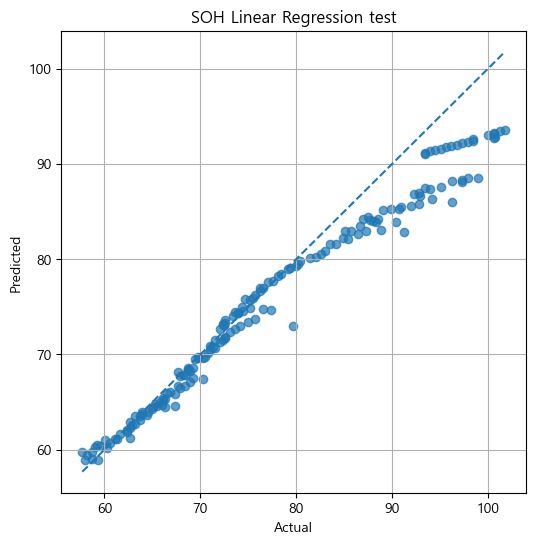

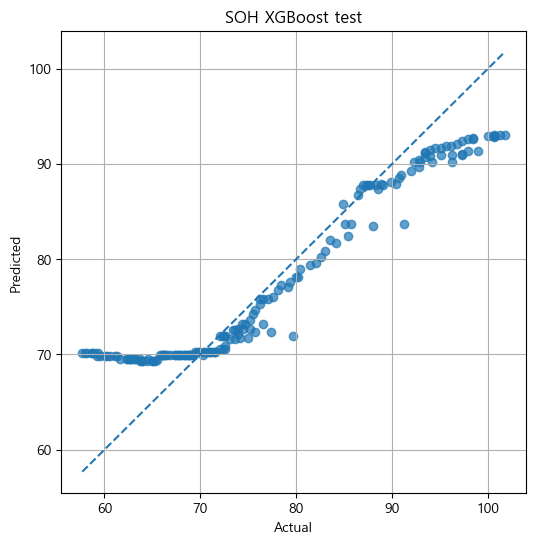

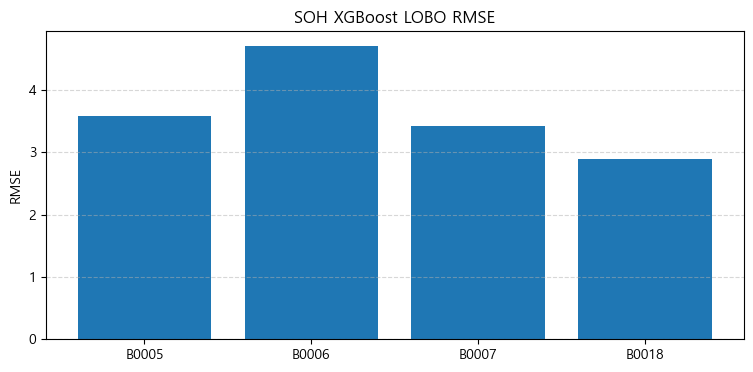

In [103]:
if SOH_RUNS['baseline_lr']['status'] == 'ok':
    print('SOH 선형회귀 계수표')
    print(SOH_RUNS['baseline_lr']['coef_df'].to_string(index=False))
    print()

if SOH_RUNS['baseline_xgb']['status'] == 'ok':
    print('SOH XGBoost 중요도')
    print(SOH_RUNS['baseline_xgb']['importance_df'].to_string(index=False))
    print()

plot_actual_vs_pred(SOH_RUNS['baseline_lr'], 'SOH Linear Regression test')
plot_actual_vs_pred(SOH_RUNS['baseline_xgb'], 'SOH XGBoost test')

plot_bar_table(
    df=SOH_RUNS['baseline_xgb']['lobo_detail_df'],
    x_col='held_out_battery',
    y_col='RMSE',
    title_text='SOH XGBoost LOBO RMSE',
    ylabel_text='RMSE'
)

## 16-3-1. B0007 Censored Battery Sanity Check


B0007은 168사이클 관측했지만 SOH 최저 70.02%로 EOL 기준(70%)에 아주 근소하게 미달.
→ '아직 죽지 않은 배터리(censored)'로 해석.
→ SOH 모델로 예측했을 때 B0007이 70% 이상으로 유지되면 모델이 올바르게 판단한 것.
→ 피드백: external sanity check로 활용


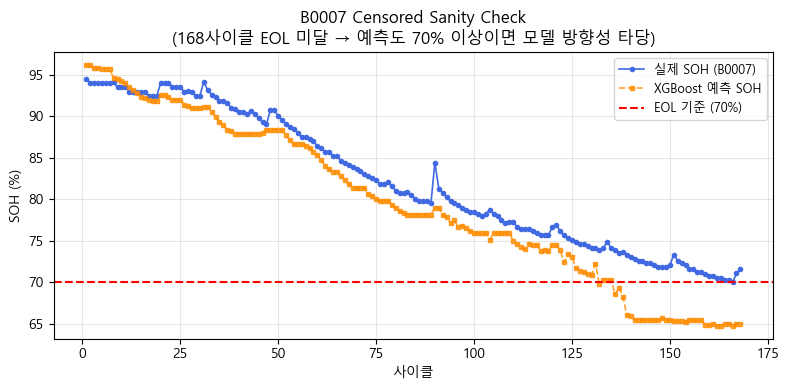

B0007 예측 SOH 최솟값: 64.81%
B0007 실제 SOH 최솟값: 70.02%
[주의] 예측이 70% 미만 → 모델이 B0007을 고장 배터리로 잘못 판단


In [104]:
# B0007 SOH sanity check
# 학습: B0007 제외한 나머지 배터리로 XGBoost SOH 모델 학습
# 예측: B0007에 적용 → 168사이클 동안 70% 이상 유지되는지 확인

if SOH_RUNS['baseline_xgb']['status'] == 'ok':
    # soh_model_df에서 B0007 제외 후 재학습
    soh_b0007_train = soh_model_df[soh_model_df['battery_id'] != 'B0007'].copy()
    soh_b0007_test  = soh_model_df[soh_model_df['battery_id'] == 'B0007'].copy()

    X_tr = soh_b0007_train[soh_feature_cols].copy()
    y_tr = soh_b0007_train['SOH_nominal'].copy()
    X_te = soh_b0007_test[soh_feature_cols].copy()

    X_tr_f, X_te_f, fill_vals = fill_missing_with_train_median(X_tr, X_te, soh_feature_cols)

    from xgboost import XGBRegressor
    m_b7 = make_xgb_regressor()
    m_b7.fit(X_tr_f, y_tr)
    b7_pred = m_b7.predict(X_te_f)

    plt.figure(figsize=(8, 4))
    plt.plot(soh_b0007_test['discharge_cycle_valid'].values,
             soh_b0007_test['SOH_nominal'].values,
             'o-', ms=3, lw=1.2, label='실제 SOH (B0007)', color='royalblue')
    plt.plot(soh_b0007_test['discharge_cycle_valid'].values, b7_pred,
             's--', ms=3, lw=1.2, label='XGBoost 예측 SOH', color='darkorange', alpha=0.8)
    plt.axhline(70, color='red', lw=1.5, ls='--', label='EOL 기준 (70%)')
    plt.xlabel('사이클')
    plt.ylabel('SOH (%)')
    plt.title('B0007 Censored Sanity Check\n'
              '(168사이클 EOL 미달 → 예측도 70% 이상이면 모델 방향성 타당)')
    plt.legend(fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'B0007 예측 SOH 최솟값: {b7_pred.min():.2f}%')
    print(f'B0007 실제 SOH 최솟값: {soh_b0007_test["SOH_nominal"].min():.2f}%')
    if b7_pred.min() >= 70:
        print('[통과] 예측이 70% 이상 유지 → B0007을 아직 살아있는 배터리로 올바르게 판단')
    else:
        print('[주의] 예측이 70% 미만 → 모델이 B0007을 고장 배터리로 잘못 판단')
else:
    print('SOH 모델 학습 실패 → sanity check 생략')


## 16-3-2. SOH-hat 생성 

- 각 배터리를 hold-out해서 나머지로 SOH 모델 학습 → 그 배터리의 SOH_hat 예측
- SOH-hat = 실제 예측 파이프라인에서 사용 가능한 값 (미래 정보 없음)
- 이후 RUL 모델에서 SOH_hat 사용 vs 정답 SOH 사용을 명확히 구분


In [105]:
# LOBO 방식으로 SOH-hat 생성
soh_hat_list = []
for bat in df_ml_rul['battery_id'].unique():
    train_soh = df_ml_soh[df_ml_soh['battery_id'] != bat]
    test_soh  = df_ml_rul[df_ml_rul['battery_id'] == bat]

    X_tr = train_soh[soh_feature_cols].copy()
    y_tr = train_soh['SOH_nominal']
    X_te = test_soh[soh_feature_cols].copy()

    X_tr_f, X_te_f, _ = fill_missing_with_train_median(X_tr, X_te, soh_feature_cols)
    m = make_xgb_regressor(); m.fit(X_tr_f, y_tr)

    tmp = test_soh[['battery_id','discharge_cycle_raw']].copy()
    tmp['SOH_hat'] = m.predict(X_te_f)
    soh_hat_list.append(tmp)

soh_hat_df = pd.concat(soh_hat_list).reset_index(drop=True)
df_ml_rul = df_ml_rul.merge(soh_hat_df, on=['battery_id','discharge_cycle_raw'], how='left')

from sklearn.metrics import mean_absolute_error, mean_squared_error
print('SOH-hat vs 정답 SOH 오차')
print(f'  MAE : {mean_absolute_error(df_ml_rul["SOH_nominal"], df_ml_rul["SOH_hat"]):.3f}')
print(f'  RMSE: {mean_squared_error(df_ml_rul["SOH_nominal"], df_ml_rul["SOH_hat"])**0.5:.3f}')
print()
print('이 오차가 RUL 모델에서 Direct→SOH-hat 성능 차이로 나타납니다')


SOH-hat vs 정답 SOH 오차
  MAE : 2.989
  RMSE: 3.858

이 오차가 RUL 모델에서 Direct→SOH-hat 성능 차이로 나타납니다


## 16-4. RUL baseline 테이블 정리

RUL baseline은 전처리 최종본 기준으로 아래 4개를 쓴다.

- `discharge_cycle_raw`
- `SOH_nominal`
- `Rct_last`
- `impedance_available`

In [106]:
RUL_TARGET_COL = 'RUL'
RUL_CYCLE_COL = 'discharge_cycle_raw'

rul_baseline_feature_cols = ['discharge_cycle_raw', 'SOH_nominal', 'Rct_last', 'impedance_available']
rul_raw_added_feature_cols = ['discharge_cycle_raw', 'SOH_nominal', 'Rct_last', 'impedance_available', 'discharge_duration_sec']

rul_model_df = ml_base_df[
    ['battery_id', 'start_time', 'filename', 'discharge_cycle_raw', 'SOH_nominal', 'RUL', 'Rct_last', 'impedance_available']
].copy()

rul_model_df = rul_model_df.sort_values(['battery_id', 'start_time']).reset_index(drop=True)

print('rul_model_df 행 수 :', len(rul_model_df))
print('rul_model_df battery 수 :', rul_model_df['battery_id'].nunique())
print()
print('RUL baseline feature :', rul_baseline_feature_cols)
rul_model_df.head()

rul_model_df 행 수 : 468
rul_model_df battery 수 : 3

RUL baseline feature : ['discharge_cycle_raw', 'SOH_nominal', 'Rct_last', 'impedance_available']


,battery_id,start_time,filename,discharge_cycle_raw,SOH_nominal,RUL,Rct_last,impedance_available
0,B0005,2008-04-02 15:25:41,05122.csv,1,92.82,124.0,NaN,0
1,B0005,2008-04-02 19:43:48,05124.csv,2,92.32,123.0,NaN,0
2,B0005,2008-04-03 00:01:06,05126.csv,3,91.77,122.0,NaN,0
3,B0005,2008-04-03 04:16:37,05128.csv,4,91.76,121.0,NaN,0
4,B0005,2008-04-03 08:33:25,05130.csv,5,91.73,120.0,NaN,0


## 16-5. raw csv에서 `discharge_duration_sec` 추출

- raw csv가 있으면 `Time`의 최대값 - 최소값으로 방전 지속 시간을 계산
- raw csv가 없으면 결측으로 둔다(오류 방지)

In [107]:
raw_path_candidates = []

if 'base_path' in globals():
    raw_path_candidates.append(base_path)

# raw_data 하위 폴더도 자동으로 탐색
raw_path_candidates.extend([
    os.path.join(base_path, 'raw_data'),   # data/raw_data/ ← VS Code 프로젝트 구조
    base_path,                              # data/
    '.',
    'data/raw_data',
    'raw_data',
    '/mnt/data',
    '/mnt/data/data'
])

# 중복 제거
raw_path_candidates = list(dict.fromkeys(raw_path_candidates))


def find_raw_file(filename):
    for folder in raw_path_candidates:
        file_path = os.path.join(folder, str(filename))
        if os.path.exists(file_path):
            return file_path
    return None


raw_duration_rows = []
missing_raw_files = []

raw_key_df = rul_model_df[['battery_id', 'start_time', 'discharge_cycle_raw', 'filename']].copy()
raw_key_df = raw_key_df[raw_key_df['start_time'].notna()].copy()
raw_key_df = raw_key_df[raw_key_df['filename'].notna()].copy()
raw_key_df = raw_key_df.drop_duplicates().copy()

for _, row in raw_key_df.iterrows():
    one_file_path = find_raw_file(row['filename'])

    if one_file_path is None:
        missing_raw_files.append(row['filename'])
        continue

    raw_csv = pd.read_csv(one_file_path)

    if 'Time' not in raw_csv.columns:
        duration_sec = np.nan
    else:
        time_s = pd.to_numeric(raw_csv['Time'], errors='coerce').dropna()

        if len(time_s) == 0:
            duration_sec = np.nan
        else:
            duration_sec = time_s.max() - time_s.min()

    raw_duration_rows.append([
        row['battery_id'],
        row['start_time'],
        row['discharge_cycle_raw'],
        row['filename'],
        duration_sec
    ])

raw_duration_df = pd.DataFrame(
    raw_duration_rows,
    columns=['battery_id', 'start_time', 'discharge_cycle_raw', 'filename', 'discharge_duration_sec']
)

print('raw_duration_df 행 수 :', len(raw_duration_df))
print('못 찾은 raw 파일 수 :', len(set(missing_raw_files)))

if len(missing_raw_files) > 0:
    print('예시 missing 파일 :', sorted(list(set(missing_raw_files)))[:10])

raw_duration_df.head()

raw_duration_df 행 수 : 468
못 찾은 raw 파일 수 : 0


,battery_id,start_time,discharge_cycle_raw,filename,discharge_duration_sec
0,B0005,2008-04-02 15:25:41,1,05122.csv,3690.234
1,B0005,2008-04-02 19:43:48,2,05124.csv,3672.344
2,B0005,2008-04-03 00:01:06,3,05126.csv,3651.641
3,B0005,2008-04-03 04:16:37,4,05128.csv,3631.563
4,B0005,2008-04-03 08:33:25,5,05130.csv,3629.172


In [108]:
rul_model_raw_df = rul_model_df.merge(
    raw_duration_df[['battery_id', 'start_time', 'discharge_cycle_raw', 'discharge_duration_sec']],
    on=['battery_id', 'start_time', 'discharge_cycle_raw'],
    how='left'
)

# 공정 비교를 위해 raw feature가 실제로 붙은 행만 비교용으로 따로 만든다.
rul_same_rows_df = rul_model_raw_df[rul_model_raw_df['discharge_duration_sec'].notna()].copy()
rul_same_rows_df = rul_same_rows_df.sort_values(['battery_id', 'start_time']).reset_index(drop=True)

print('rul_model_raw_df 전체 행 수 :', len(rul_model_raw_df))
print('rul_same_rows_df 비교 행 수 :', len(rul_same_rows_df))
print('rul_same_rows_df battery 수 :', rul_same_rows_df['battery_id'].nunique())
print()
print('RUL raw-added feature :', rul_raw_added_feature_cols)
rul_same_rows_df.head()

rul_model_raw_df 전체 행 수 : 468
rul_same_rows_df 비교 행 수 : 468
rul_same_rows_df battery 수 : 3

RUL raw-added feature : ['discharge_cycle_raw', 'SOH_nominal', 'Rct_last', 'impedance_available', 'discharge_duration_sec']


,battery_id,start_time,filename,discharge_cycle_raw,SOH_nominal,RUL,Rct_last,impedance_available,discharge_duration_sec
0,B0005,2008-04-02 15:25:41,05122.csv,1,92.82,124.0,NaN,0,3690.234
1,B0005,2008-04-02 19:43:48,05124.csv,2,92.32,123.0,NaN,0,3672.344
2,B0005,2008-04-03 00:01:06,05126.csv,3,91.77,122.0,NaN,0,3651.641
3,B0005,2008-04-03 04:16:37,05128.csv,4,91.76,121.0,NaN,0,3631.563
4,B0005,2008-04-03 08:33:25,05130.csv,5,91.73,120.0,NaN,0,3629.172


## 16-6. 변수 지도

변수 지도를 보고 지금 어떤 변수에서 무엇을 확인해야 하는지 바로 찾을 수 있게 정리.

selected_rul_run : 현재 실제로 보고 있는 모델 결과 묶음.

In [109]:
# feature 정의
RUL_TARGET_COL = 'RUL'

# 계층 1: 사이클 + impedance만 (가장 현실적)
rul_direct_feature_cols    = ['discharge_cycle_raw', 'Rct_last', 'impedance_available']

# 계층 2: 사이클 + SOH_hat (예측된 SOH, 실제 파이프라인)
rul_soh_hat_feature_cols   = ['discharge_cycle_raw', 'SOH_hat', 'Rct_last', 'impedance_available']

# 계층 3: 사이클 + SOH_nominal 정답 (성능 상한선)
rul_oracle_feature_cols    = ['discharge_cycle_raw', 'SOH_nominal', 'Rct_last', 'impedance_available']

# 계층 4: oracle + discharge_duration_sec (가장 강한 proxy)
rul_rawproxy_feature_cols  = ['discharge_cycle_raw', 'SOH_nominal', 'Rct_last',
                               'impedance_available', 'discharge_duration_sec']

# 기존 baseline/raw_added 호환 명칭
rul_baseline_feature_cols  = rul_oracle_feature_cols       # 원본 호환
rul_raw_added_feature_cols = rul_rawproxy_feature_cols     # 원본 호환

print('RUL 4계층 feature 구성')
print(f'  1. direct   : {rul_direct_feature_cols}')
print(f'  2. soh_hat  : {rul_soh_hat_feature_cols}')
print(f'  3. oracle   : {rul_oracle_feature_cols}')
print(f'  4. raw_proxy: {rul_rawproxy_feature_cols}')


RUL 4계층 feature 구성
  1. direct   : ['discharge_cycle_raw', 'Rct_last', 'impedance_available']
  2. soh_hat  : ['discharge_cycle_raw', 'SOH_hat', 'Rct_last', 'impedance_available']
  3. oracle   : ['discharge_cycle_raw', 'SOH_nominal', 'Rct_last', 'impedance_available']
  4. raw_proxy: ['discharge_cycle_raw', 'SOH_nominal', 'Rct_last', 'impedance_available', 'discharge_duration_sec']


## 16-7-1. pre-EOL vs 전체 구분

- `df_ml_rul`: 전체 (pre-EOL + post-EOL)
- `df_ml_rul_preeol`: RUL > 0만 (pre-EOL)
- 두 가지를 분리해서 평가


In [110]:
df_ml_rul_preeol = df_ml_rul[df_ml_rul['RUL'] > 0].copy()

print(f'전체 RUL: {len(df_ml_rul)}행')
print(f'  RUL=0 (post-EOL): {(df_ml_rul["RUL"]==0).sum()}행 ({(df_ml_rul["RUL"]==0).mean()*100:.1f}%)')
print(f'  RUL>0 (pre-EOL) : {len(df_ml_rul_preeol)}행 ({len(df_ml_rul_preeol)/len(df_ml_rul)*100:.1f}%)')
print()
print('[주의] RUL=0 행이 많으면 모델이 고장 후 구간을 잘 맞추면서 RMSE가 과도하게 낮아질 수 있음')
print('따라서 pre-EOL(RUL>0) 구간 성능을 반드시 별도 확인해야 함')


전체 RUL: 468행
  RUL=0 (post-EOL): 140행 (29.9%)
  RUL>0 (pre-EOL) : 328행 (70.1%)

[주의] RUL=0 행이 많으면 모델이 고장 후 구간을 잘 맞추면서 RMSE가 과도하게 낮아질 수 있음
따라서 pre-EOL(RUL>0) 구간 성능을 반드시 별도 확인해야 함


## 16-7. RUL 4계층 학습 


In [128]:
# ════════════════════════════════════════════════════════
# RUL_RUNS 초기화 — 이 줄은 전체 노트북에서 딱 한 번만!
# 중간에 다시 쓰면 앞 결과 전부 소멸
# ════════════════════════════════════════════════════════
RUL_RUNS = {}

# ── [중간 확인 1] df_ml_rul 상태 검증 ─────────────────────────────
print('=' * 55)
print('[중간 확인 1] RUL 학습 데이터 검증')
print('=' * 55)
print('df_ml_rul 행수     :', len(df_ml_rul))
print('df_ml_rul 배터리   :', sorted(df_ml_rul['battery_id'].unique()))
print('RUL 범위           :', df_ml_rul['RUL'].min(), '~', df_ml_rul['RUL'].max())
print('SOH_hat 결측       :', df_ml_rul['SOH_hat'].isna().sum() if 'SOH_hat' in df_ml_rul.columns else '컬럼 없음')
print('rul_same_rows_df 행수:', len(rul_same_rows_df), '(raw csv 있는 행)')
print()
print('feature 구성')
print('  1_direct  :', rul_direct_feature_cols)
print('  2_soh_hat :', rul_soh_hat_feature_cols)
print('  3_oracle  :', rul_oracle_feature_cols)
print('  4_rawproxy:', rul_rawproxy_feature_cols)


[중간 확인 1] RUL 학습 데이터 검증
df_ml_rul 행수     : 468
df_ml_rul 배터리   : ['B0005', 'B0006', 'B0018']
RUL 범위           : 0.0 ~ 124.0
SOH_hat 결측       : 0
rul_same_rows_df 행수: 468 (raw csv 있는 행)

feature 구성
  1_direct  : ['discharge_cycle_raw', 'Rct_last', 'impedance_available']
  2_soh_hat : ['discharge_cycle_raw', 'SOH_hat', 'Rct_last', 'impedance_available']
  3_oracle  : ['discharge_cycle_raw', 'SOH_nominal', 'Rct_last', 'impedance_available']
  4_rawproxy: ['discharge_cycle_raw', 'SOH_nominal', 'Rct_last', 'impedance_available', 'discharge_duration_sec']


In [ ]:
# ── 1계층: direct (cycle+impedance, 가장 현실적) ─────────────────
print('\n[1계층] direct 학습 중...')
RUL_RUNS['direct_lr'] = run_single_split_regression(
    model_df=df_ml_rul, feature_cols=rul_direct_feature_cols,
    target_col=RUL_TARGET_COL, model_factory=LinearRegression)
RUL_RUNS['direct_lr'] = add_linear_coefficients(RUL_RUNS['direct_lr'])
RUL_RUNS['direct_lr']['lobo_detail_df'], RUL_RUNS['direct_lr']['lobo_mean_df'] = run_lobo_regression(
    model_df=df_ml_rul, feature_cols=rul_direct_feature_cols,
    target_col=RUL_TARGET_COL, model_factory=LinearRegression)

RUL_RUNS['direct_xgb'] = run_single_split_regression(
    model_df=df_ml_rul, feature_cols=rul_direct_feature_cols,
    target_col=RUL_TARGET_COL, model_factory=make_xgb_regressor)
RUL_RUNS['direct_xgb'] = add_xgb_importance(RUL_RUNS['direct_xgb'])
RUL_RUNS['direct_xgb'] = add_shap_summary(RUL_RUNS['direct_xgb'])
RUL_RUNS['direct_xgb']['lobo_detail_df'], RUL_RUNS['direct_xgb']['lobo_mean_df'] = run_lobo_regression(
    model_df=df_ml_rul, feature_cols=rul_direct_feature_cols,
    target_col=RUL_TARGET_COL, model_factory=make_xgb_regressor)

print('  direct_lr  status:', RUL_RUNS['direct_lr']['status'])
print('  direct_xgb status:', RUL_RUNS['direct_xgb']['status'])

# ── 2계층: soh_hat (예측 SOH, 실제 파이프라인) ────────────────────
print('\n[2계층] soh_hat 학습 중...')
if 'SOH_hat' not in df_ml_rul.columns:
    print(' SOH_hat 컬럼 없음. SOH-hat 생성 셀을 먼저 실행하세요.')
else:
    RUL_RUNS['soh_hat_lr'] = run_single_split_regression(
        model_df=df_ml_rul, feature_cols=rul_soh_hat_feature_cols,
        target_col=RUL_TARGET_COL, model_factory=LinearRegression)
    RUL_RUNS['soh_hat_lr'] = add_linear_coefficients(RUL_RUNS['soh_hat_lr'])
    RUL_RUNS['soh_hat_lr']['lobo_detail_df'], RUL_RUNS['soh_hat_lr']['lobo_mean_df'] = run_lobo_regression(
        model_df=df_ml_rul, feature_cols=rul_soh_hat_feature_cols,
        target_col=RUL_TARGET_COL, model_factory=LinearRegression)

    RUL_RUNS['soh_hat_xgb'] = run_single_split_regression(
        model_df=df_ml_rul, feature_cols=rul_soh_hat_feature_cols,
        target_col=RUL_TARGET_COL, model_factory=make_xgb_regressor)
    RUL_RUNS['soh_hat_xgb'] = add_xgb_importance(RUL_RUNS['soh_hat_xgb'])
    RUL_RUNS['soh_hat_xgb'] = add_shap_summary(RUL_RUNS['soh_hat_xgb'])
    RUL_RUNS['soh_hat_xgb']['lobo_detail_df'], RUL_RUNS['soh_hat_xgb']['lobo_mean_df'] = run_lobo_regression(
        model_df=df_ml_rul, feature_cols=rul_soh_hat_feature_cols,
        target_col=RUL_TARGET_COL, model_factory=make_xgb_regressor)
    print('  soh_hat_lr  status:', RUL_RUNS['soh_hat_lr']['status'])
    print('  soh_hat_xgb status:', RUL_RUNS['soh_hat_xgb']['status'])

# ── 3계층: oracle (정답 SOH, 성능 상한선) ────────────────────────
print('\n[3계층] oracle 학습 중...')
RUL_RUNS['baseline_lr'] = run_single_split_regression(
    model_df=df_ml_rul, feature_cols=rul_oracle_feature_cols,
    target_col=RUL_TARGET_COL, model_factory=LinearRegression)
RUL_RUNS['baseline_lr'] = add_linear_coefficients(RUL_RUNS['baseline_lr'])
RUL_RUNS['baseline_lr']['lobo_detail_df'], RUL_RUNS['baseline_lr']['lobo_mean_df'] = run_lobo_regression(
    model_df=df_ml_rul, feature_cols=rul_oracle_feature_cols,
    target_col=RUL_TARGET_COL, model_factory=LinearRegression)

RUL_RUNS['baseline_xgb'] = run_single_split_regression(
    model_df=df_ml_rul, feature_cols=rul_oracle_feature_cols,
    target_col=RUL_TARGET_COL, model_factory=make_xgb_regressor)
RUL_RUNS['baseline_xgb'] = add_xgb_importance(RUL_RUNS['baseline_xgb'])
RUL_RUNS['baseline_xgb'] = add_shap_summary(RUL_RUNS['baseline_xgb'])
RUL_RUNS['baseline_xgb']['lobo_detail_df'], RUL_RUNS['baseline_xgb']['lobo_mean_df'] = run_lobo_regression(
    model_df=df_ml_rul, feature_cols=rul_oracle_feature_cols,
    target_col=RUL_TARGET_COL, model_factory=make_xgb_regressor)
print('  baseline_lr  status:', RUL_RUNS['baseline_lr']['status'])
print('  baseline_xgb status:', RUL_RUNS['baseline_xgb']['status'])

# ── 4계층: raw_proxy (oracle+duration, 가장 강한 proxy) ───────────
print('\n[4계층] raw_proxy 학습 중...')
if len(rul_same_rows_df) == 0:
    print('  rul_same_rows_df 비어있음. raw csv 없으면 raw_proxy 계층 건너뜀.')
    print('     raw csv가 있으면 raw_data 폴더 경로를 base_path에 지정 후 재실행.')
else:
    RUL_RUNS['raw_added_lr'] = run_single_split_regression(
        model_df=rul_same_rows_df, feature_cols=rul_rawproxy_feature_cols,
        target_col=RUL_TARGET_COL, model_factory=LinearRegression)
    RUL_RUNS['raw_added_lr'] = add_linear_coefficients(RUL_RUNS['raw_added_lr'])
    RUL_RUNS['raw_added_lr']['lobo_detail_df'], RUL_RUNS['raw_added_lr']['lobo_mean_df'] = run_lobo_regression(
        model_df=rul_same_rows_df, feature_cols=rul_rawproxy_feature_cols,
        target_col=RUL_TARGET_COL, model_factory=LinearRegression)

    RUL_RUNS['raw_added_xgb'] = run_single_split_regression(
        model_df=rul_same_rows_df, feature_cols=rul_rawproxy_feature_cols,
        target_col=RUL_TARGET_COL, model_factory=make_xgb_regressor)
    RUL_RUNS['raw_added_xgb'] = add_xgb_importance(RUL_RUNS['raw_added_xgb'])
    RUL_RUNS['raw_added_xgb'] = add_shap_summary(RUL_RUNS['raw_added_xgb'])
    RUL_RUNS['raw_added_xgb']['lobo_detail_df'], RUL_RUNS['raw_added_xgb']['lobo_mean_df'] = run_lobo_regression(
        model_df=rul_same_rows_df, feature_cols=rul_rawproxy_feature_cols,
        target_col=RUL_TARGET_COL, model_factory=make_xgb_regressor)
    print('  raw_added_lr  status:', RUL_RUNS['raw_added_lr']['status'])
    print('  raw_added_xgb status:', RUL_RUNS['raw_added_xgb']['status'])

# ── [중간 확인 2] RUL_RUNS 현재 키 전체 출력 ─────────────────────
print()
print('=' * 55)
print('[중간 확인 2] RUL_RUNS 현재 저장된 키 목록')
print('=' * 55)
print('키 목록:', list(RUL_RUNS.keys()))
print()
print('%-20s %-10s %-10s %-10s' % ('키', 'status', 'test RMSE', 'LOBO RMSE'))
print('-' * 55)
for k, v in RUL_RUNS.items():
    if v['status'] == 'ok':
        test_rmse = v['metric_df'].loc[1,'RMSE'] if v['metric_df'] is not None else 'N/A'
        lobo_rmse = v['lobo_mean_df'].loc[0,'RMSE'] if v['lobo_mean_df'] is not None else 'N/A'
        print('%-20s %-10s %-10s %-10s' % (k, v['status'], test_rmse, lobo_rmse))
    else:
        print('%-20s %-10s' % (k, v['status']))
print()
print('[주의] 위 목록에 direct_lr, direct_xgb, soh_hat_xgb, baseline_xgb가 모두 있어야 정상입니다.')
print('만약 일부가 없다면 위 셀에서 오류가 발생했거나 RUL_RUNS가 중간에 초기화된 것입니다.')



[1계층] direct 학습 중...
  direct_lr  status: ok
  direct_xgb status: ok

[2계층] soh_hat 학습 중...
  soh_hat_lr  status: ok
  soh_hat_xgb status: ok

[3계층] oracle 학습 중...
  baseline_lr  status: ok
  baseline_xgb status: ok

[4계층] raw_proxy 학습 중...
  raw_added_lr  status: ok
  raw_added_xgb status: ok

[중간 확인 2] RUL_RUNS 현재 저장된 키 목록
키 목록: ['direct_lr', 'direct_xgb', 'soh_hat_lr', 'soh_hat_xgb', 'baseline_lr', 'baseline_xgb', 'raw_added_lr', 'raw_added_xgb']

키                    status     test RMSE  LOBO RMSE 
-------------------------------------------------------
direct_lr            ok         26.2819    21.1822   
direct_xgb           ok         13.7841    11.2081   
soh_hat_lr           ok         16.5529    14.1664   
soh_hat_xgb          ok         12.2608    11.0706   
baseline_lr          ok         24.8808    20.9226   
baseline_xgb         ok         12.7997    11.6188   
raw_added_lr         ok         15.3556    13.6847   
raw_added_xgb        ok         12.6       10.946    

[

## 16-7-3. LightGBM 설치 확인 및 함수 정의

LightGBM import → 함수 정의 → 설치 확인을 한 셀에서 순서대로 실행합니다.
이 순서가 보장되어야 아래 학습 셀에서 `make_lgbm_regressor`를 사용할 수 있습니다.


In [ ]:
# ════════════════════════════════════════════════════════
# LightGBM 설치 확인 (함수 정의는 공통함수 셀에 있음)
# ════════════════════════════════════════════════════════

try:
    from lightgbm import LGBMRegressor
    import lightgbm as _lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False

print('[중간 확인 3] LightGBM 설치 확인')
if LIGHTGBM_AVAILABLE:
    print('  LightGBM 설치됨. 버전:', _lgb.__version__)
else:
    print('  LightGBM 미설치 → pip install lightgbm 후 Kernel Restart')

print()
print('[중간 확인 3-1] 현재 RUL_RUNS 키 (LightGBM 추가 전):')
print(' ', list(RUL_RUNS.keys()))
print()
print('[중간 확인 3-2] LightGBM 함수 사용 가능 여부')
try:
    _ = make_lgbm_regressor
    print('  make_lgbm_regressor 정의 확인')
except NameError:
    print('  make_lgbm_regressor 미정의 → 공통함수 셀(16-1)을 먼저 실행하세요')
try:
    _ = add_lgbm_importance
    print('  add_lgbm_importance 정의 확인')
except NameError:
    print('  add_lgbm_importance 미정의 → 공통함수 셀(16-1)을 먼저 실행하세요')


[중간 확인 3] LightGBM 설치 확인
  ✅ LightGBM 설치됨. 버전: 4.6.0

[중간 확인 3-1] 현재 RUL_RUNS 키 (LightGBM 추가 전):
  ['direct_lr', 'direct_xgb', 'soh_hat_lr', 'soh_hat_xgb', 'baseline_lr', 'baseline_xgb', 'raw_added_lr', 'raw_added_xgb']

[중간 확인 3-2] LightGBM 함수 사용 가능 여부
  ✅ make_lgbm_regressor 정의 확인
  ✅ add_lgbm_importance 정의 확인


In [ ]:
# LightGBM 4계층 학습 — RUL_RUNS에 누적 (초기화 절대 안 함)
if LIGHTGBM_AVAILABLE:
    print('[LightGBM] 3계층(oracle) 학습 중...')
    RUL_RUNS['baseline_lgb'] = run_single_split_regression(
        model_df=df_ml_rul, feature_cols=rul_oracle_feature_cols,
        target_col=RUL_TARGET_COL, model_factory=make_lgbm_regressor,
        group_col='battery_id')
    RUL_RUNS['baseline_lgb']['lobo_detail_df'], RUL_RUNS['baseline_lgb']['lobo_mean_df'] = run_lobo_regression(
        model_df=df_ml_rul, feature_cols=rul_oracle_feature_cols,
        target_col=RUL_TARGET_COL, model_factory=make_lgbm_regressor,
        group_col='battery_id')
    RUL_RUNS['baseline_lgb'] = add_lgbm_importance(RUL_RUNS['baseline_lgb'])
    RUL_RUNS['baseline_lgb'] = add_shap_summary(RUL_RUNS['baseline_lgb'])
    print('  baseline_lgb status:', RUL_RUNS['baseline_lgb']['status'])

    if len(rul_same_rows_df) > 0:
        print('[LightGBM] 4계층(raw_proxy) 학습 중...')
        RUL_RUNS['raw_added_lgb'] = run_single_split_regression(
            model_df=rul_same_rows_df, feature_cols=rul_rawproxy_feature_cols,
            target_col=RUL_TARGET_COL, model_factory=make_lgbm_regressor,
            group_col='battery_id')
        RUL_RUNS['raw_added_lgb']['lobo_detail_df'], RUL_RUNS['raw_added_lgb']['lobo_mean_df'] = run_lobo_regression(
            model_df=rul_same_rows_df, feature_cols=rul_rawproxy_feature_cols,
            target_col=RUL_TARGET_COL, model_factory=make_lgbm_regressor,
            group_col='battery_id')
        RUL_RUNS['raw_added_lgb'] = add_lgbm_importance(RUL_RUNS['raw_added_lgb'])
        RUL_RUNS['raw_added_lgb'] = add_shap_summary(RUL_RUNS['raw_added_lgb'])
        print('  raw_added_lgb status:', RUL_RUNS['raw_added_lgb']['status'])
    else:
        print('[LightGBM] raw csv 없어 4계층 건너뜀')
else:
    print('[건너뜀] LightGBM 미설치')

# ── [중간 확인 4] 최종 RUL_RUNS 키 전체 ─────────────────────────
print()
print('=' * 55)
print('[중간 확인 4] LightGBM 추가 후 RUL_RUNS 전체 키')
print('=' * 55)
print('키 목록:', list(RUL_RUNS.keys()))
expected = ['direct_lr','direct_xgb','soh_hat_lr','soh_hat_xgb',
            'baseline_lr','baseline_xgb']
missing = [k for k in expected if k not in RUL_RUNS]
if missing:
    print('누락 키:', missing)
    print('   → 해당 계층 학습 셀을 다시 확인하세요')
else:
    print('필수 키 6개 모두 존재')


[LightGBM] 3계층(oracle) 학습 중...
  baseline_lgb status: ok
[LightGBM] 4계층(raw_proxy) 학습 중...
  raw_added_lgb status: ok

[중간 확인 4] LightGBM 추가 후 RUL_RUNS 전체 키
키 목록: ['direct_lr', 'direct_xgb', 'soh_hat_lr', 'soh_hat_xgb', 'baseline_lr', 'baseline_xgb', 'raw_added_lr', 'raw_added_xgb', 'baseline_lgb', 'raw_added_lgb']
✅ 필수 키 6개 모두 존재


## 16-7-4. 4계층 비교표 생성

모든 계층이 RUL_RUNS에 있을 때만 표에 포함됩니다.
raw csv 없이 실행하면 raw_proxy 계층은 표에서 자동으로 빠집니다.


In [115]:
# ── [중간 확인 5] 비교표 생성 전 키 확인 ───────────────────────
print('[중간 확인 5] 비교표에 들어갈 키 확인')
all_possible_keys = [
    ('direct_lr',     'LinearRegression', '1_direct'),
    ('direct_xgb',    'XGBoost',          '1_direct'),
    ('soh_hat_lr',    'LinearRegression', '2_soh_hat'),
    ('soh_hat_xgb',   'XGBoost',          '2_soh_hat'),
    ('baseline_lr',   'LinearRegression', '3_oracle'),
    ('baseline_xgb',  'XGBoost',          '3_oracle'),
    ('raw_added_lr',  'LinearRegression', '4_raw_proxy'),
    ('raw_added_xgb', 'XGBoost',          '4_raw_proxy'),
    ('baseline_lgb',  'LightGBM',         '3_oracle'),
    ('raw_added_lgb', 'LightGBM',         '4_raw_proxy'),
]
active_keys = [(k, m, f) for k, m, f in all_possible_keys if k in RUL_RUNS and RUL_RUNS[k]['status'] == 'ok']
print('  표에 포함될 키:', [k for k, m, f in active_keys])
print()

ordered_run_keys  = [k for k, m, f in active_keys]
model_name_map    = {k: m for k, m, f in active_keys}
feature_name_map  = {k: f for k, m, f in active_keys}

rul_compare_test_df = make_compare_metric_df(
    run_dict=RUL_RUNS, ordered_keys=ordered_run_keys,
    model_name_map=model_name_map, feature_name_map=feature_name_map)
rul_compare_lobo_df = make_compare_lobo_df(
    run_dict=RUL_RUNS, ordered_keys=ordered_run_keys,
    model_name_map=model_name_map, feature_name_map=feature_name_map)

print('RUL 4계층 single split 성능표')
print(rul_compare_test_df.to_string(index=False))
print()
print('RUL 4계층 LOBO 평균 성능표')
print(rul_compare_lobo_df.to_string(index=False))
print()
print('[해석 가이드]')
print('  1_direct  = 현실에서 사용 가능한 성능')
print('  2_soh_hat = 예측 SOH 파이프라인 성능')
print('  3_oracle  = 정답 SOH를 알 때 상한선 (현실 불가)')
print('  4_raw_proxy = oracle + duration (raw csv 필요, 방전 후에만 가능)')


[중간 확인 5] 비교표에 들어갈 키 확인
  표에 포함될 키: ['direct_lr', 'direct_xgb', 'soh_hat_lr', 'soh_hat_xgb', 'baseline_lr', 'baseline_xgb', 'raw_added_lr', 'raw_added_xgb', 'baseline_lgb', 'raw_added_lgb']

RUL 4계층 single split 성능표
           model feature_set     MAE    RMSE     R2
LinearRegression    1_direct 24.0610 26.2819 0.5939
         XGBoost    1_direct 12.3617 13.7841 0.8883
LinearRegression   2_soh_hat 15.1635 16.5529 0.8389
         XGBoost   2_soh_hat  9.9143 12.2608 0.9116
LinearRegression    3_oracle 22.6403 24.8808 0.6360
         XGBoost    3_oracle 10.4256 12.7997 0.9037
LinearRegression 4_raw_proxy 13.4040 15.3556 0.8614
         XGBoost 4_raw_proxy 10.6300 12.6000 0.9067
        LightGBM    3_oracle 11.2588 14.0459 0.8840
        LightGBM 4_raw_proxy 11.4518 13.8495 0.8872

RUL 4계층 LOBO 평균 성능표
           model feature_set     MAE    RMSE     R2
LinearRegression    1_direct 18.0082 21.1822 0.6661
         XGBoost    1_direct  9.5440 11.2081 0.9023
LinearRegression   2_soh_hat 12.865

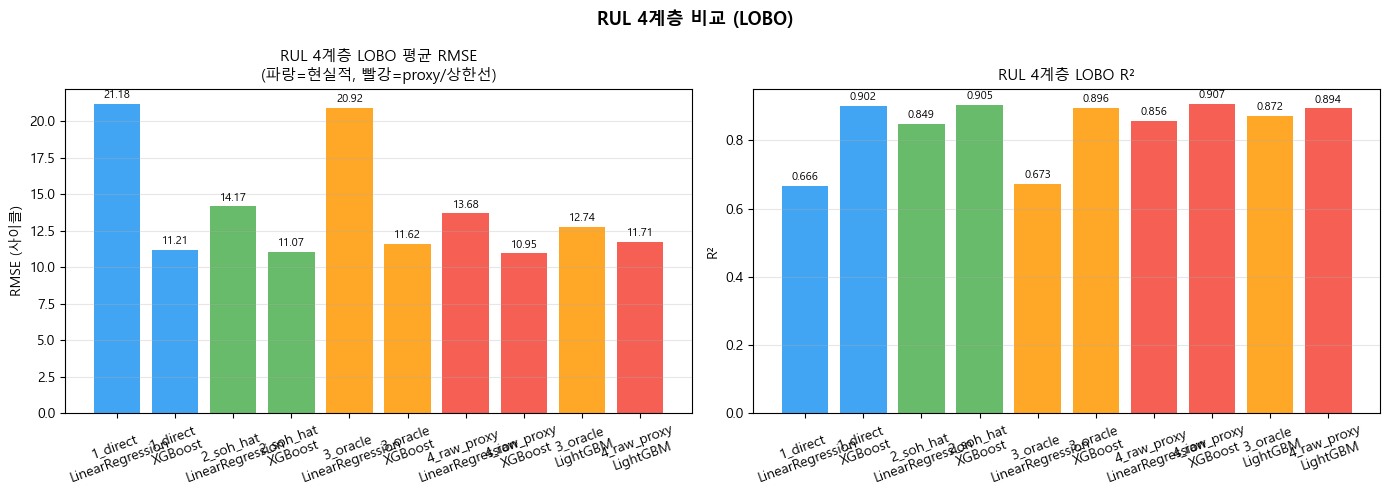

In [116]:
# 4계층 LOBO RMSE 바차트
if len(rul_compare_lobo_df) == 0:
    print('비교 데이터 없음')
else:
    rul_compare_lobo_plot_df = rul_compare_lobo_df.copy()
    rul_compare_lobo_plot_df['label'] = (
        rul_compare_lobo_plot_df['feature_set'] + '\n' + rul_compare_lobo_plot_df['model']
    )
    tier_color = {'1_direct':'#2196F3','2_soh_hat':'#4CAF50',
                  '3_oracle':'#FF9800','4_raw_proxy':'#F44336'}
    bar_colors = [tier_color.get(f, '#9E9E9E')
                  for f in rul_compare_lobo_plot_df['feature_set']]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    bars = axes[0].bar(rul_compare_lobo_plot_df['label'],
                       rul_compare_lobo_plot_df['RMSE'], color=bar_colors, alpha=0.85)
    axes[0].bar_label(bars, fmt='%.2f', fontsize=8, padding=2)
    axes[0].set_title('RUL 4계층 LOBO 평균 RMSE\n(파랑=현실적, 빨강=proxy/상한선)', fontsize=11)
    axes[0].set_ylabel('RMSE (사이클)')
    axes[0].tick_params(axis='x', labelrotation=20)
    axes[0].grid(axis='y', alpha=0.3)

    bars2 = axes[1].bar(rul_compare_lobo_plot_df['label'],
                        rul_compare_lobo_plot_df['R2'], color=bar_colors, alpha=0.85)
    axes[1].bar_label(bars2, fmt='%.3f', fontsize=8, padding=2)
    axes[1].set_title('RUL 4계층 LOBO R²', fontsize=11)
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', labelrotation=20)
    axes[1].grid(axis='y', alpha=0.3)

    plt.suptitle('RUL 4계층 비교 (LOBO)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


## 16-7-5. pre-EOL 전용 성능 평가

RUL=0 행이 약 30% → 이 행들이 RMSE를 낮춰 보이게 만들 수 있음.
라벨과 실제 들어간 모델이 일치하는지 키 이름으로 명시 확인.


In [ ]:
# ── [중간 확인 6] pre-EOL 비교 전 키 일치 확인 ────────────────
print('[중간 확인 6] pre-EOL 비교에 쓸 키와 실제 feature 확인')
check_keys = [
    ('direct_xgb',   '1_direct',   rul_direct_feature_cols),
    ('soh_hat_xgb',  '2_soh_hat',  rul_soh_hat_feature_cols),
    ('baseline_xgb', '3_oracle',   rul_oracle_feature_cols),
]
for key, label, expected_feats in check_keys:
    if key not in RUL_RUNS:
        print(' %s 없음 → %s 생략' % (key, label))
    elif RUL_RUNS[key]['status'] != 'ok':
        print(' %s 학습 실패 → %s 생략' % (key, label))
    else:
        actual_feats = RUL_RUNS[key]['feature_cols']
        match = (actual_feats == expected_feats)
        mark = 'O' if match else 'X 불일치!'
        print('  %s 키=%s 라벨=%s feature=%s' % (mark, key, label, actual_feats))
print()

# ── pre-EOL LOBO ────────────────────────────────────────────────
preeol_runs = {}
for key, label, _ in check_keys:
    if key not in RUL_RUNS or RUL_RUNS[key]['status'] != 'ok':
        continue
    feats = RUL_RUNS[key]['feature_cols']
    detail, mean = run_lobo_regression(
        model_df=df_ml_rul_preeol, feature_cols=feats,
        target_col=RUL_TARGET_COL, model_factory=make_xgb_regressor)
    preeol_runs[key] = {'detail': detail, 'mean': mean, 'label': label}

print('XGBoost: 전체 vs pre-EOL LOBO RMSE 비교')
print('%-15s %-12s %-12s %s' % ('계층', '전체RMSE', 'preEOL_RMSE', '해석'))
print('-' * 60)
for key, label, _ in check_keys:
    if key not in RUL_RUNS or key not in preeol_runs:
        print('%-15s %-12s %-12s' % (label, 'N/A', 'N/A'))
        continue
    full_rmse = RUL_RUNS[key]['lobo_mean_df'].loc[0,'RMSE'] \
                if RUL_RUNS[key]['lobo_mean_df'] is not None else 'N/A'
    pe_rmse   = preeol_runs[key]['mean'].loc[0,'RMSE'] \
                if preeol_runs[key]['mean'] is not None else 'N/A'
    if isinstance(full_rmse, float) and isinstance(pe_rmse, float):
        interp = '부풀려짐' if pe_rmse > full_rmse else '정상'
    else:
        interp = ''
    print('%-15s %-12s %-12s %s' % (label, str(full_rmse), str(pe_rmse), interp))
print()
print('[해석] preEOL RMSE > 전체RMSE 이면, RUL=0 행이 전체 성능을 부풀린 것')


[중간 확인 6] pre-EOL 비교에 쓸 키와 실제 feature 확인
  ✅ 키=direct_xgb 라벨=1_direct feature=['discharge_cycle_raw', 'Rct_last', 'impedance_available']
  ✅ 키=soh_hat_xgb 라벨=2_soh_hat feature=['discharge_cycle_raw', 'SOH_hat', 'Rct_last', 'impedance_available']
  ✅ 키=baseline_xgb 라벨=3_oracle feature=['discharge_cycle_raw', 'SOH_nominal', 'Rct_last', 'impedance_available']

XGBoost: 전체 vs pre-EOL LOBO RMSE 비교
계층              전체RMSE       preEOL_RMSE  해석
------------------------------------------------------------
1_direct        11.2081      12.3283      부풀려짐
2_soh_hat       11.0706      12.2049      부풀려짐
3_oracle        11.6188      13.1655      부풀려짐

[해석] preEOL RMSE > 전체RMSE 이면, RUL=0 행이 전체 성능을 부풀린 것


## 16-8. 최종 선택 모델 및 SHAP 해석

- 1순위: `direct_xgb` (가장 현실적)
- 2순위: `soh_hat_xgb` (파이프라인)
- 3순위: `baseline_xgb` (oracle, 상한선)


In [ ]:
# 최종 선택: direct → soh_hat → baseline 우선순위
priority = ['direct_xgb', 'soh_hat_xgb', 'baseline_xgb']
selected_rul_run_key = None
for key in priority:
    if key in RUL_RUNS and RUL_RUNS[key]['status'] == 'ok':
        selected_rul_run_key = key
        break

if selected_rul_run_key is None:
    print('선택 가능한 모델 없음. RUL_RUNS 확인 필요.')
    print('    현재 키:', list(RUL_RUNS.keys()))
else:
    selected_rul_run = RUL_RUNS[selected_rul_run_key]
    print('선택된 모델       :', selected_rul_run_key)
    print('실제 feature 목록 :', selected_rul_run['feature_cols'])
    print('선택 이유         : 현실 예측 파이프라인에서 사용 가능한 모델 우선')
    print()
    print('[중간 확인 7] 선택 모델 test 성능')
    print(selected_rul_run['metric_df'].to_string(index=False))
    print()
    if selected_rul_run['lobo_mean_df'] is not None:
        print('[중간 확인 7-1] 선택 모델 LOBO 평균')
        print(selected_rul_run['lobo_mean_df'].to_string(index=False))
    print()
    # train vs test 과적합 확인
    train_rmse = selected_rul_run['metric_df'].loc[0,'RMSE']
    test_rmse  = selected_rul_run['metric_df'].loc[1,'RMSE']
    ratio = test_rmse / train_rmse if train_rmse > 0 else float('inf')
    print('[중간 확인 7-2] 과적합 점검')
    print('  train RMSE:', train_rmse, ' / test RMSE:', test_rmse)
    print('  test/train 비율:', round(ratio, 2))
    if ratio > 2.0:
        print('과적합 의심: test가 train보다 2배 이상 나쁨')
    else:
        print(' 과적합 없음 (비율 2.0 이하)')


선택된 모델       : direct_xgb
실제 feature 목록 : ['discharge_cycle_raw', 'Rct_last', 'impedance_available']
선택 이유         : 현실 예측 파이프라인에서 사용 가능한 모델 우선

[중간 확인 7] 선택 모델 test 성능
  set     MAE    RMSE     R2
train  1.9042  2.5140 0.9947
 test 12.3617 13.7841 0.8883

[중간 확인 7-1] 선택 모델 LOBO 평균
  MAE    RMSE     R2
9.544 11.2081 0.9023

[중간 확인 7-2] 과적합 점검
  train RMSE: 2.514  / test RMSE: 13.7841
  test/train 비율: 5.48
  ⚠️  과적합 의심: test가 train보다 2배 이상 나쁨


선택 모델 중요도
            feature  importance
discharge_cycle_raw    0.918083
impedance_available    0.048918
           Rct_last    0.032999



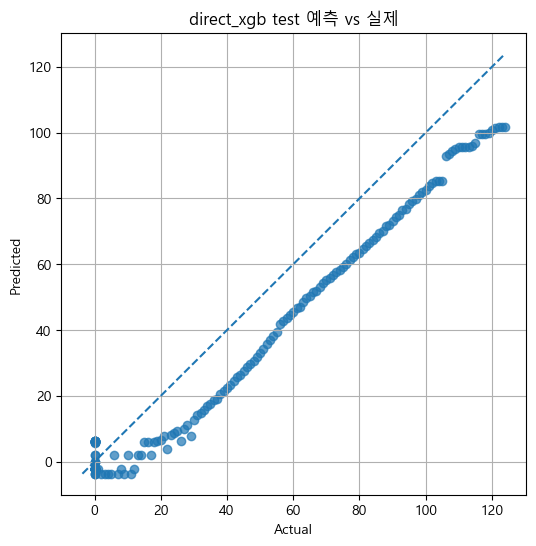

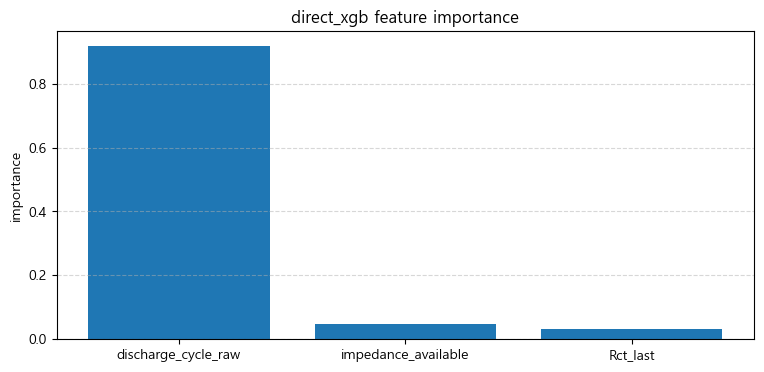


[해석 주의]
  discharge_cycle_raw가 가장 중요하면: 사이클 번호가 지배적 예측 변수
  Rct_last가 높은 순위이면: impedance가 추가 정보를 줌
  impedance가 하위권이면: 현재 데이터에서 Rct는 보조 신호에 가까움


In [119]:
if selected_rul_run_key is not None and selected_rul_run['status'] == 'ok':
    print('선택 모델 중요도')
    if selected_rul_run.get('importance_df') is not None:
        print(selected_rul_run['importance_df'].to_string(index=False))
    print()
    plot_actual_vs_pred(selected_rul_run, '%s test 예측 vs 실제' % selected_rul_run_key)

    if selected_rul_run.get('importance_df') is not None:
        plot_bar_table(
            df=selected_rul_run['importance_df'],
            x_col='feature', y_col='importance',
            title_text='%s feature importance' % selected_rul_run_key,
            ylabel_text='importance')
    print()
    print('[해석 주의]')
    print('  discharge_cycle_raw가 가장 중요하면: 사이클 번호가 지배적 예측 변수')
    print('  Rct_last가 높은 순위이면: impedance가 추가 정보를 줌')
    print('  impedance가 하위권이면: 현재 데이터에서 Rct는 보조 신호에 가까움')


In [120]:
if selected_rul_run_key is not None and selected_rul_run['status'] == 'ok':
    if selected_rul_run.get('shap_mean_df') is not None:
        print('선택 모델 SHAP 평균 절대값')
        print(selected_rul_run['shap_mean_df'].to_string(index=False))
        plot_bar_table(
            df=selected_rul_run['shap_mean_df'],
            x_col='feature', y_col='mean_abs_shap',
            title_text='%s SHAP mean(|value|)' % selected_rul_run_key,
            ylabel_text='mean abs shap')

        if SHAP_AVAILABLE:
            import shap
            shap.summary_plot(selected_rul_run['shap_values'],
                              selected_rul_run['X_test'], show=False)
            plt.show()
    else:
        print('SHAP 없음:', selected_rul_run.get('shap_error', '이유 불명'))


SHAP 없음: SHAP import 실패


In [121]:
if selected_rul_run_key is not None and selected_rul_run['status'] == 'ok':
    pred_df = selected_rul_run['pred_df']
    test_pred_df = pred_df[pred_df['set'] == 'test']
    print('선택 모델 test 예측 결과 (처음 20행)')
    print(test_pred_df[['battery_id','start_time','y_true','y_pred','abs_error']].head(20))


선택 모델 test 예측 결과 (처음 20행)
    battery_id          start_time  y_true      y_pred  abs_error
300      B0005 2008-04-02 15:25:41   124.0  101.731056  22.268944
301      B0005 2008-04-02 19:43:48   123.0  101.731056  21.268944
302      B0005 2008-04-03 00:01:06   122.0  101.731056  20.268944
303      B0005 2008-04-03 04:16:37   121.0  101.516861  19.483139
304      B0005 2008-04-03 08:33:25   120.0  100.695969  19.304031
305      B0005 2008-04-03 12:55:10   119.0   99.894783  19.105217
306      B0005 2008-04-03 17:17:16   118.0   99.661186  18.338814
307      B0005 2008-04-03 21:28:14   117.0   99.661186  17.338814
308      B0005 2008-04-04 01:38:15   116.0   99.661186  16.338814
309      B0005 2008-04-04 05:48:08   115.0   96.732597  18.267403
310      B0005 2008-04-04 09:57:19   114.0   95.974190  18.025810
311      B0005 2008-04-04 17:56:27   113.0   95.533890  17.466110
312      B0005 2008-04-04 22:01:54   112.0   95.533890  16.466110
313      B0005 2008-04-05 02:20:26   111.0   95.53

In [ ]:
# 필요하면 머신러닝용 중간 결과도 저장
ml_save_candidates = [save_dir if 'save_dir' in globals() else base_path, '.', '/mnt/data']
ml_save_dir = None

for one_dir in ml_save_candidates:
    try:
        os.makedirs(one_dir, exist_ok=True)
        test_file = os.path.join(one_dir, '__ml_write_test__.tmp')
        with open(test_file, 'w', encoding='utf-8') as f:
            f.write('ok')
        os.remove(test_file)
        ml_save_dir = one_dir
        break
    except Exception:
        continue

if ml_save_dir is None:
    raise PermissionError('폴더 못찾음')

ml_base_df.to_csv(os.path.join(ml_save_dir, 'df_ml_with_filename.csv'), index=False)
soh_model_df.to_csv(os.path.join(ml_save_dir, 'soh_model_df.csv'), index=False)
rul_model_df.to_csv(os.path.join(ml_save_dir, 'rul_model_df.csv'), index=False)
rul_model_raw_df.to_csv(os.path.join(ml_save_dir, 'rul_model_raw_df.csv'), index=False)

print('머신러닝 중간 테이블 저장 완료')
print(os.path.join(ml_save_dir, 'df_ml_with_filename.csv'))
print(os.path.join(ml_save_dir, 'soh_model_df.csv'))
print(os.path.join(ml_save_dir, 'rul_model_df.csv'))
print(os.path.join(ml_save_dir, 'rul_model_raw_df.csv'))

머신러닝 중간 테이블 저장 완료
data\df_ml_with_filename.csv
data\soh_model_df.csv
data\rul_model_df.csv
data\rul_model_raw_df.csv


## 17. 모델 비교 시각화


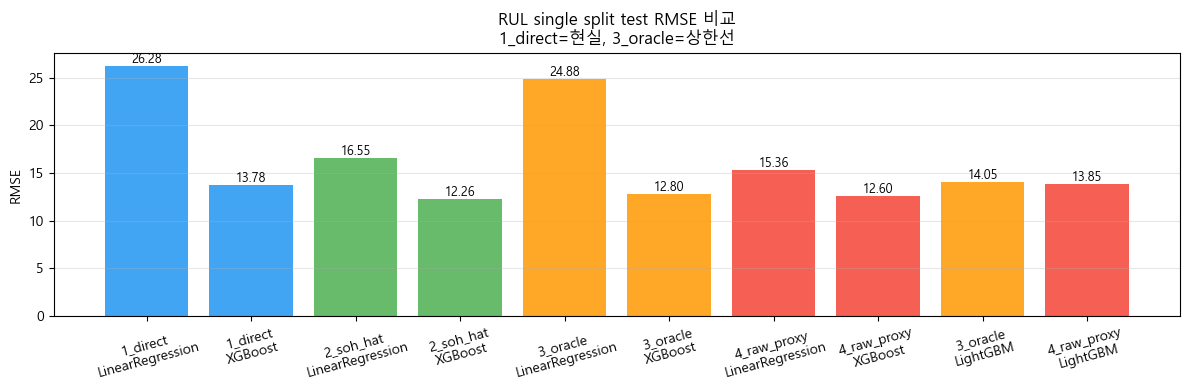

In [123]:
# 1. single split test RMSE 비교
if len(rul_compare_test_df) > 0:
    rul_compare_test_df['label'] = rul_compare_test_df['feature_set'] + '\n' + rul_compare_test_df['model']
    tier_color = {'1_direct':'#2196F3','2_soh_hat':'#4CAF50','3_oracle':'#FF9800','4_raw_proxy':'#F44336'}
    c = [tier_color.get(f,'#9E9E9E') for f in rul_compare_test_df['feature_set']]
    plt.figure(figsize=(12,4))
    bars = plt.bar(rul_compare_test_df['label'], rul_compare_test_df['RMSE'], color=c, alpha=0.85)
    plt.bar_label(bars, fmt='%.2f', fontsize=9)
    plt.title('RUL single split test RMSE 비교\n1_direct=현실, 3_oracle=상한선')
    plt.ylabel('RMSE'); plt.grid(axis='y', alpha=0.3)
    plt.tick_params(axis='x', labelrotation=15)
    plt.tight_layout(); plt.show()
else:
    print('비교 데이터 없음')


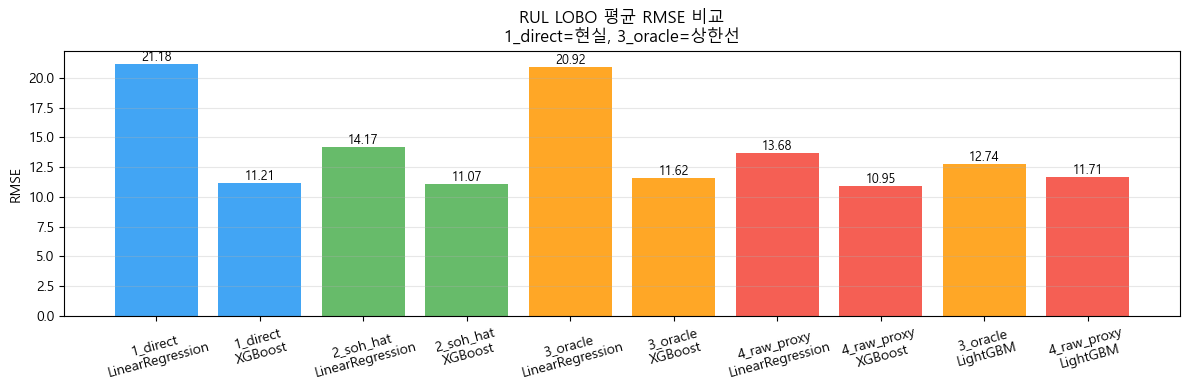

In [124]:
# 2. LOBO 평균 RMSE 비교
if len(rul_compare_lobo_df) > 0:
    rul_compare_lobo_df['label'] = rul_compare_lobo_df['feature_set'] + '\n' + rul_compare_lobo_df['model']
    tier_color = {'1_direct':'#2196F3','2_soh_hat':'#4CAF50','3_oracle':'#FF9800','4_raw_proxy':'#F44336'}
    c = [tier_color.get(f,'#9E9E9E') for f in rul_compare_lobo_df['feature_set']]
    plt.figure(figsize=(12,4))
    bars = plt.bar(rul_compare_lobo_df['label'], rul_compare_lobo_df['RMSE'], color=c, alpha=0.85)
    plt.bar_label(bars, fmt='%.2f', fontsize=9)
    plt.title('RUL LOBO 평균 RMSE 비교\n1_direct=현실, 3_oracle=상한선')
    plt.ylabel('RMSE'); plt.grid(axis='y', alpha=0.3)
    plt.tick_params(axis='x', labelrotation=15)
    plt.tight_layout(); plt.show()


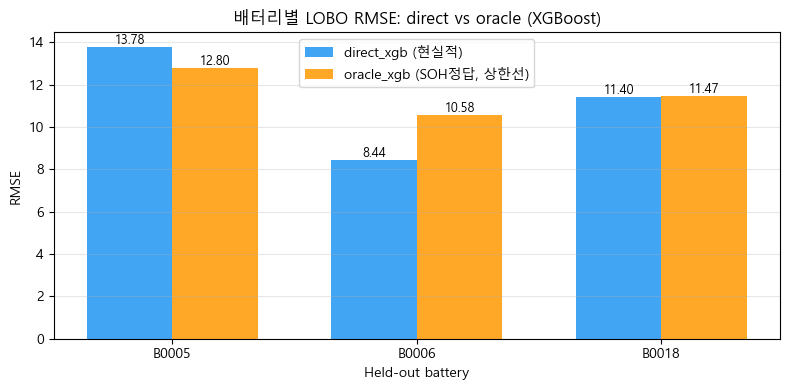

In [125]:
# 3. battery별 LOBO: direct_xgb vs oracle_xgb
rul_xgb_lobo_compare_df = pd.DataFrame()
if ('direct_xgb' in RUL_RUNS and 'baseline_xgb' in RUL_RUNS and
    RUL_RUNS['direct_xgb']['status']=='ok' and RUL_RUNS['baseline_xgb']['status']=='ok' and
    RUL_RUNS['direct_xgb']['lobo_detail_df'] is not None and
    RUL_RUNS['baseline_xgb']['lobo_detail_df'] is not None):
    rul_xgb_lobo_compare_df = (
        RUL_RUNS['direct_xgb']['lobo_detail_df'][['held_out_battery','RMSE']]
        .rename(columns={'RMSE':'direct_rmse'})
        .merge(RUL_RUNS['baseline_xgb']['lobo_detail_df'][['held_out_battery','RMSE']]
               .rename(columns={'RMSE':'oracle_rmse'}), on='held_out_battery', how='inner')
    )

if len(rul_xgb_lobo_compare_df) > 0:
    x = np.arange(len(rul_xgb_lobo_compare_df)); w = 0.35
    plt.figure(figsize=(8,4))
    b1 = plt.bar(x-w/2, rul_xgb_lobo_compare_df['direct_rmse'], width=w, label='direct_xgb (현실적)', color='#2196F3', alpha=0.85)
    b2 = plt.bar(x+w/2, rul_xgb_lobo_compare_df['oracle_rmse'], width=w, label='oracle_xgb (SOH정답, 상한선)', color='#FF9800', alpha=0.85)
    plt.xticks(x, rul_xgb_lobo_compare_df['held_out_battery'])
    plt.bar_label(b1, fmt='%.2f', fontsize=9); plt.bar_label(b2, fmt='%.2f', fontsize=9)
    plt.xlabel('Held-out battery'); plt.ylabel('RMSE')
    plt.title('배터리별 LOBO RMSE: direct vs oracle (XGBoost)')
    plt.legend(); plt.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print('direct_xgb 또는 baseline_xgb 결과 없음')


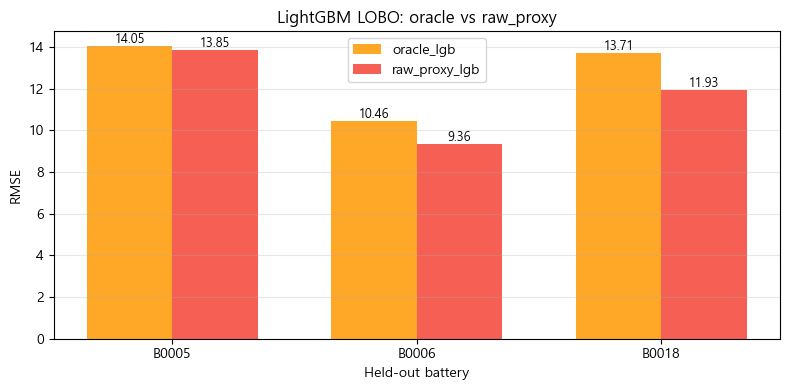

In [126]:
# 4. LightGBM baseline vs raw_added (있을 때만)
rul_lgb_lobo_compare_df = pd.DataFrame()
if ('baseline_lgb' in RUL_RUNS and 'raw_added_lgb' in RUL_RUNS and
    RUL_RUNS['baseline_lgb']['status']=='ok' and RUL_RUNS['raw_added_lgb']['status']=='ok' and
    RUL_RUNS['baseline_lgb']['lobo_detail_df'] is not None and
    RUL_RUNS['raw_added_lgb']['lobo_detail_df'] is not None):
    rul_lgb_lobo_compare_df = (
        RUL_RUNS['baseline_lgb']['lobo_detail_df'][['held_out_battery','RMSE']]
        .rename(columns={'RMSE':'oracle_lgb_rmse'})
        .merge(RUL_RUNS['raw_added_lgb']['lobo_detail_df'][['held_out_battery','RMSE']]
               .rename(columns={'RMSE':'raw_proxy_lgb_rmse'}), on='held_out_battery', how='inner')
    )

if len(rul_lgb_lobo_compare_df) > 0:
    x = np.arange(len(rul_lgb_lobo_compare_df)); w = 0.35
    plt.figure(figsize=(8,4))
    b1 = plt.bar(x-w/2, rul_lgb_lobo_compare_df['oracle_lgb_rmse'], width=w, label='oracle_lgb', color='#FF9800', alpha=0.85)
    b2 = plt.bar(x+w/2, rul_lgb_lobo_compare_df['raw_proxy_lgb_rmse'], width=w, label='raw_proxy_lgb', color='#F44336', alpha=0.85)
    plt.xticks(x, rul_lgb_lobo_compare_df['held_out_battery'])
    plt.bar_label(b1, fmt='%.2f', fontsize=9); plt.bar_label(b2, fmt='%.2f', fontsize=9)
    plt.xlabel('Held-out battery'); plt.ylabel('RMSE')
    plt.title('LightGBM LOBO: oracle vs raw_proxy')
    plt.legend(); plt.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print('LightGBM 결과 없음 (미설치 또는 raw csv 없음)')


## 17.2 LightGBM NaN 자체 처리 vs median imputation 비교

- LinearRegression: imputation 필요 → median 유지
- LightGBM: NaN 유지 + impedance_available 함께 사용하는 방식 시도


In [ ]:
# LightGBM NaN 처리 vs median imputation 비교
if not LIGHTGBM_AVAILABLE:
    print('[건너뜀] LightGBM 미설치')
else:
    from sklearn.model_selection import GroupShuffleSplit
    from sklearn.metrics import mean_squared_error

    # 방식 1: median imputation
    lgb_imputed = run_single_split_regression(
        model_df=df_ml_rul, feature_cols=rul_oracle_feature_cols,
        target_col=RUL_TARGET_COL, model_factory=make_lgbm_regressor)

    # 방식 2: NaN 유지 (LightGBM 자체 처리)
    work = df_ml_rul.copy()
    for col in rul_oracle_feature_cols + ['RUL']:
        work[col] = pd.to_numeric(work[col], errors='coerce')
    work = work[work['RUL'].notna()].copy()

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
    X = work[rul_oracle_feature_cols]
    y = work['RUL']
    g = work['battery_id']
    tr_idx, te_idx = next(splitter.split(X, y, g))

    m_nan = make_lgbm_regressor_nan()
    m_nan.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    pred_nan = m_nan.predict(X.iloc[te_idx])
    rmse_nan = mean_squared_error(y.iloc[te_idx], pred_nan) ** 0.5

    if lgb_imputed['status'] == 'ok':
        rmse_imp = lgb_imputed['metric_df'].loc[1, 'RMSE']
        print('LightGBM NaN 처리 방식 비교 (oracle, single split test RMSE)')
        print('  median imputation : RMSE=%.2f' % rmse_imp)
        print('  NaN 유지(자체처리): RMSE=%.2f' % rmse_nan)
        print()
        if rmse_nan < rmse_imp:
            print('→ NaN 유지 방식이 더 나음')
        else:
            print('→ 이 데이터에서는 imputation과 차이 없음')
    else:
        print('[건너뜀] lgb_imputed 학습 실패:', lgb_imputed.get('reason'))


LightGBM NaN 처리 방식 비교 (oracle, single split test RMSE)
  median imputation : RMSE=14.05
  NaN 유지(자체처리): RMSE=12.88

→ NaN 유지 방식이 더 나음 (LightGBM 권장)
